In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
import pandas as pd

# ============================================================
# LOAD DATASETS
# ============================================================

CROP_FILE = r".\crop_yield.csv"
SOIL_FILE = r".\state_soil_data.csv"
WEATHER_FILE = r".\state_weather_data_1997_2020.csv"


crop_df = pd.read_csv(CROP_FILE)

soil_df = pd.read_csv(SOIL_FILE)

weather_df = pd.read_csv(WEATHER_FILE)


print("Datasets loaded successfully!")
print()

print("Crop Yield Dataset:")
print(crop_df.shape)

print()

print("Soil Dataset:")
print(soil_df.shape)

print()

print("Weather Dataset:")
print(weather_df.shape)

Datasets loaded successfully!

Crop Yield Dataset:
(19689, 9)

Soil Dataset:
(30, 5)

Weather Dataset:
(720, 5)


In [4]:
print("=" * 70)
print("CROP YIELD DATASET COLUMNS")
print("=" * 70)

print(crop_df.columns.tolist())


print()
print("=" * 70)
print("SOIL DATASET COLUMNS")
print("=" * 70)

print(soil_df.columns.tolist())


print()
print("=" * 70)
print("WEATHER DATASET COLUMNS")
print("=" * 70)

print(weather_df.columns.tolist())

CROP YIELD DATASET COLUMNS
['crop', 'year', 'season', 'state', 'area', 'production', 'fertilizer', 'pesticide', 'yield']

SOIL DATASET COLUMNS
['state', 'N', 'P', 'K', 'pH']

WEATHER DATASET COLUMNS
['state', 'year', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent']


In [5]:
print("="*70)
print("CROP YIELD")
print("="*70)

display(crop_df.head())

print("="*70)
print("SOIL")
print("="*70)

display(soil_df.head())

print("="*70)
print("WEATHER")
print("="*70)

display(weather_df.head())

CROP YIELD


,crop,year,season,state,area,production,fertilizer,pesticide,yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909


SOIL


,state,N,P,K,pH
0,Andhra Pradesh,78,45,22,6.8
1,Arunachal Pradesh,55,15,35,5.5
2,Assam,60,18,38,5.8
3,Bihar,85,30,25,7.2
4,Chhattisgarh,70,35,20,6.5


WEATHER


,state,year,avg_temp_c,total_rainfall_mm,avg_humidity_percent
0,Andhra Pradesh,1997,28.21,1191.08,69.56
1,Andhra Pradesh,1998,28.21,1100.41,71.95
2,Andhra Pradesh,1999,28.03,603.67,66.91
3,Andhra Pradesh,2000,27.74,1070.25,70.73
4,Andhra Pradesh,2001,28.08,910.13,68.69


In [6]:
print("=" * 70)
print("CROP YIELD DATA TYPES")
print("=" * 70)

crop_df.info()

print("=" * 70)
print("SOIL DATA TYPES")
print("=" * 70)

soil_df.info()

print("=" * 70)
print("WEATHER DATA TYPES")
print("=" * 70)

weather_df.info()

CROP YIELD DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   crop        19689 non-null  object 
 1   year        19689 non-null  int64  
 2   season      19689 non-null  object 
 3   state       19689 non-null  object 
 4   area        19689 non-null  float64
 5   production  19689 non-null  int64  
 6   fertilizer  19689 non-null  float64
 7   pesticide   19689 non-null  float64
 8   yield       19689 non-null  float64
dtypes: float64(4), int64(2), object(3)
memory usage: 1.4+ MB
SOIL DATA TYPES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   state   30 non-null     object 
 1   N       30 non-null     int64  
 2   P       30 non-null     int64  
 3   K       30 non-null     int64  
 4   pH      30 n

In [7]:
print("=" * 70)
print("CROP YIELD DATA TYPES")
print("=" * 70)

print(crop_df.isnull())

print("=" * 70)
print("SOIL DATA TYPES")
print("=" * 70)

print(soil_df.isnull())

print("=" * 70)
print("WEATHER DATA TYPES")
print("=" * 70)

print(weather_df.isnull())

CROP YIELD DATA TYPES
        crop   year  season  state   area  production  fertilizer  pesticide  \
0      False  False   False  False  False       False       False      False   
1      False  False   False  False  False       False       False      False   
2      False  False   False  False  False       False       False      False   
3      False  False   False  False  False       False       False      False   
4      False  False   False  False  False       False       False      False   
...      ...    ...     ...    ...    ...         ...         ...        ...   
19684  False  False   False  False  False       False       False      False   
19685  False  False   False  False  False       False       False      False   
19686  False  False   False  False  False       False       False      False   
19687  False  False   False  False  False       False       False      False   
19688  False  False   False  False  False       False       False      False   

       yield  
0 

# ============================================================
# getting ready for merging the datasets 
# ============================================================

In [8]:
crop = crop_df.copy()
soil = soil_df.copy()
weather = weather_df.copy()

In [9]:
crop.columns = crop.columns.str.strip()
soil.columns = soil.columns.str.strip()
weather.columns = weather.columns.str.strip()

print(crop.columns.tolist())
print(soil.columns.tolist())
print(weather.columns.tolist())

['crop', 'year', 'season', 'state', 'area', 'production', 'fertilizer', 'pesticide', 'yield']
['state', 'N', 'P', 'K', 'pH']
['state', 'year', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent']


In [10]:
crop_states = set(crop["state"].unique())
soil_states = set(soil["state"].unique())
weather_states = set(soil["state"].unique())

print("Crop states:", len(crop_states))
print("Soil states:", len(soil_states))
print("Weather states:", len(weather_states))

print("\nStates in crop but not soil:")
print(sorted(crop_states - soil_states))
print("\nStates in crop but not weather:")
print(sorted(crop_states - weather_states))

Crop states: 30
Soil states: 30
Weather states: 30

States in crop but not soil:
[]

States in crop but not weather:
[]


# ============================================================
# Know Performing the Actual Joins
# ============================================================

In [11]:
merged_df = crop.merge(
    soil,
    on="state",
    how="left",
)

print("After soil merge:")
print(merged_df.shape)

print("\nColumns:")
print(merged_df.columns.tolist())

After soil merge:
(19689, 13)

Columns:
['crop', 'year', 'season', 'state', 'area', 'production', 'fertilizer', 'pesticide', 'yield', 'N', 'P', 'K', 'pH']


In [12]:
merged_df = merged_df.merge(
    weather,
    on=["state","year"],
    how="left"
)

print("After weather merge:")
print(merged_df.shape)

print("\nColumns:")
print(merged_df.columns.tolist())

After weather merge:
(19689, 16)

Columns:
['crop', 'year', 'season', 'state', 'area', 'production', 'fertilizer', 'pesticide', 'yield', 'N', 'P', 'K', 'pH', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent']


In [13]:
print("Missing Values:")
print(merged_df.isnull().sum())

Missing Values:
crop                    0
year                    0
season                  0
state                   0
area                    0
production              0
fertilizer              0
pesticide               0
yield                   0
N                       0
P                       0
K                       0
pH                      0
avg_temp_c              0
total_rainfall_mm       0
avg_humidity_percent    0
dtype: int64


In [14]:
display(
    merged_df.head(10)
)

,crop,year,season,state,area,production,fertilizer,pesticide,yield,N,P,K,pH,avg_temp_c,total_rainfall_mm,avg_humidity_percent
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087,60,18,38,5.8,22.41,1468.92,70.71
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435,60,18,38,5.8,22.41,1468.92,70.71
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333,60,18,38,5.8,22.41,1468.92,70.71
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739,60,18,38,5.8,22.41,1468.92,70.71
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909,60,18,38,5.8,22.41,1468.92,70.71
5,Dry chillies,1997,Whole Year,Assam,13587.0,9073,1293074.79,4211.97,0.643636,60,18,38,5.8,22.41,1468.92,70.71
6,Gram,1997,Rabi,Assam,2979.0,1507,283511.43,923.49,0.465455,60,18,38,5.8,22.41,1468.92,70.71
7,Jute,1997,Kharif,Assam,94520.0,904095,8995468.40,29301.20,9.919565,60,18,38,5.8,22.41,1468.92,70.71
8,Linseed,1997,Rabi,Assam,10098.0,5158,961026.66,3130.38,0.461364,60,18,38,5.8,22.41,1468.92,70.71
9,Maize,1997,Kharif,Assam,19216.0,14721,1828786.72,5956.96,0.615652,60,18,38,5.8,22.41,1468.92,70.71


# ============================================================
# CHECK RELATIONSHIP BETWEEN PRODUCTION, AREA AND YIELD
# ============================================================

In [15]:
merged_df["calculated_yield"] = (
    merged_df["production"] / merged_df["area"]
)

merged_df["yield_difference"] = (
    merged_df["yield"] - merged_df["calculated_yield"]
)

display(
    merged_df[
        [
            "crop",
            "area",
            "production",
            "yield",
            "calculated_yield",
            "yield_difference"
        ]
        ].head(20)
)

,crop,area,production,yield,calculated_yield,yield_difference
0,Arecanut,73814.0,56708,0.796087,0.768255,0.027832
1,Arhar/Tur,6637.0,4685,0.710435,0.705891,0.004544
2,Castor seed,796.0,22,0.238333,0.027638,0.210695
3,Coconut,19656.0,126905000,5238.051739,6456.298331,-1218.246592
4,Cotton(lint),1739.0,794,0.420909,0.456584,-0.035675
5,Dry chillies,13587.0,9073,0.643636,0.667771,-0.024134
6,Gram,2979.0,1507,0.465455,0.505874,-0.040420
7,Jute,94520.0,904095,9.919565,9.565118,0.354447
8,Linseed,10098.0,5158,0.461364,0.510794,-0.049431
9,Maize,19216.0,14721,0.615652,0.766080,-0.150428


In [16]:
print(
    merged_df[
        [
            "area",
            "production",
            "yield",
            "calculated_yield"
        ]
        ].corr()
)

                      area  production     yield  calculated_yield
area              1.000000    0.037441  0.001858          0.001996
production        0.037441    1.000000  0.570809          0.574604
yield             0.001858    0.570809  1.000000          0.996518
calculated_yield  0.001996    0.574604  0.996518          1.000000


In [17]:
print("Yield statistics:")
print(
    merged_df["yield"].describe()
)

print("\nProduction statistics:")
print(
    merged_df["production"].describe()
)

Yield statistics:
count    19689.000000
mean        79.954009
std        878.306193
min          0.000000
25%          0.600000
50%          1.030000
75%          2.388889
max      21105.000000
Name: yield, dtype: float64

Production statistics:
count    1.968900e+04
mean     1.643594e+07
std      2.630568e+08
min      0.000000e+00
25%      1.393000e+03
50%      1.380400e+04
75%      1.227180e+05
max      6.326000e+09
Name: production, dtype: float64


# ============================================================
# First, let's understand the crop distribution
# ============================================================

In [18]:
print("Number of uniqur Crops:")
print(merged_df["crop"].nunique())

print("\nCrops:")
print(
    sorted(
        merged_df["crop"].unique()
    )
)

Number of uniqur Crops:
55

Crops:
['Arecanut', 'Arhar/Tur', 'Bajra', 'Banana', 'Barley', 'Black pepper', 'Cardamom', 'Cashewnut', 'Castor seed', 'Coconut ', 'Coriander', 'Cotton(lint)', 'Cowpea(Lobia)', 'Dry chillies', 'Garlic', 'Ginger', 'Gram', 'Groundnut', 'Guar seed', 'Horse-gram', 'Jowar', 'Jute', 'Khesari', 'Linseed', 'Maize', 'Masoor', 'Mesta', 'Moong(Green Gram)', 'Moth', 'Niger seed', 'Oilseeds total', 'Onion', 'Other  Rabi pulses', 'Other Cereals', 'Other Kharif pulses', 'Other Summer Pulses', 'Peas & beans (Pulses)', 'Potato', 'Ragi', 'Rapeseed &Mustard', 'Rice', 'Safflower', 'Sannhamp', 'Sesamum', 'Small millets', 'Soyabean', 'Sugarcane', 'Sunflower', 'Sweet potato', 'Tapioca', 'Tobacco', 'Turmeric', 'Urad', 'Wheat', 'other oilseeds']


In [19]:
crop_yield_stats = (
    merged_df
    .groupby("crop")["yield"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .sort_values(
        "mean",
        ascending=False
    )
)
display(crop_yield_stats)

,count,mean,median,min,max
crop,,,,,
Coconut,172,8652.000199,8466.315523,0.000000,21105.000000
Sugarcane,605,51.727439,53.158158,0.290000,165.000000
Banana,245,26.851128,17.948750,0.000000,126.387692
Tapioca,201,16.667301,11.117778,0.000000,42.097857
Potato,628,13.331718,10.175284,0.000000,311.020000
Onion,454,13.247525,9.192846,0.000000,381.420000
Sweet potato,273,9.240788,8.512727,0.000000,26.339444
Jute,181,7.555393,8.146250,0.000000,25.430556
Ginger,323,6.442202,4.887500,0.000000,36.357826


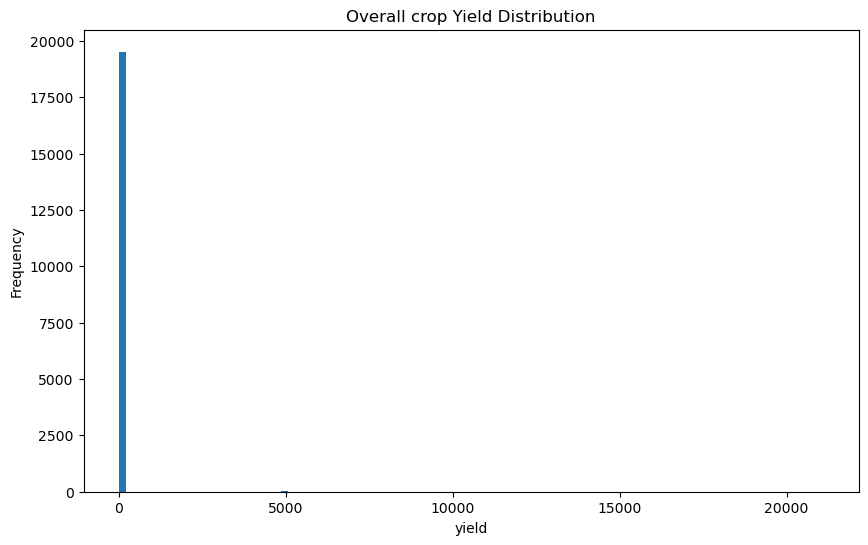

In [20]:
plt.figure(figsize=(10,6))

plt.hist(
    merged_df["yield"],
    bins=100
)

plt.xlabel("yield")
plt.ylabel("Frequency")
plt.title("Overall crop Yield Distribution")

plt.show()

# ============================================================
# Cleaning the dataset
# ============================================================

In [21]:
categoricial_columns = [
    "crop",
    "season",
    "state"
]

for column in categoricial_columns:
    merged_df[column]=(
        merged_df[column]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+"," ",regex=True)
    )

print("Unique crops after cleaning:")
print(merged_df["crop"].nunique())

print("\nUnique crops:")
print(sorted(merged_df["crop"].unique()))

Unique crops after cleaning:
55

Unique crops:
['Arecanut', 'Arhar/Tur', 'Bajra', 'Banana', 'Barley', 'Black pepper', 'Cardamom', 'Cashewnut', 'Castor seed', 'Coconut', 'Coriander', 'Cotton(lint)', 'Cowpea(Lobia)', 'Dry chillies', 'Garlic', 'Ginger', 'Gram', 'Groundnut', 'Guar seed', 'Horse-gram', 'Jowar', 'Jute', 'Khesari', 'Linseed', 'Maize', 'Masoor', 'Mesta', 'Moong(Green Gram)', 'Moth', 'Niger seed', 'Oilseeds total', 'Onion', 'Other Cereals', 'Other Kharif pulses', 'Other Rabi pulses', 'Other Summer Pulses', 'Peas & beans (Pulses)', 'Potato', 'Ragi', 'Rapeseed &Mustard', 'Rice', 'Safflower', 'Sannhamp', 'Sesamum', 'Small millets', 'Soyabean', 'Sugarcane', 'Sunflower', 'Sweet potato', 'Tapioca', 'Tobacco', 'Turmeric', 'Urad', 'Wheat', 'other oilseeds']


In [22]:
duplicate_count = merged_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [23]:
missing_values = merged_df.isnull().sum()

print(missing_values)

crop                    0
year                    0
season                  0
state                   0
area                    0
production              0
fertilizer              0
pesticide               0
yield                   0
N                       0
P                       0
K                       0
pH                      0
avg_temp_c              0
total_rainfall_mm       0
avg_humidity_percent    0
calculated_yield        0
yield_difference        0
dtype: int64


In [24]:
zero_yield_count = (
    merged_df["yield"] == 0
).sum()

total_rows = len(merged_df)

print("zero_yield rows:", zero_yield_count)

print(
    "Percentage:",
    round(
        zero_yield_count / total_rows * 100,
        2
    ),
    "%"
)

zero_yield rows: 112
Percentage: 0.57 %


In [25]:

display(
    merged_df[
        [
            "crop",
            "state",
            "year",
            "season",
            "area",
            "production",
            "fertilizer",
            "pesticide",
            "yield"
        ]
    ]
    .sort_values(
        "yield",
        ascending=False
    )
    .head(30)
)

,crop,state,year,season,area,production,fertilizer,pesticide,yield
13962,Coconut,Telangana,2014,Whole Year,439.0,9265095,66271.44,144.87,21105.00000
5771,Coconut,Andhra Pradesh,2019,Whole Year,104027.0,1912224000,17867677.52,38489.99,16935.05846
13406,Coconut,Telangana,2013,Whole Year,428.0,6956712,61841.72,115.56,16254.00000
5425,Coconut,Andhra Pradesh,2018,Whole Year,104530.0,1571100000,16954766.00,36585.50,15636.63231
3610,Coconut,Andhra Pradesh,2012,Whole Year,99825.0,1670659000,15053610.00,30945.75,14794.63000
18015,Coconut,Puducherry,2012,Whole Year,1564.0,20297000,235851.20,484.84,14410.51667
3052,Coconut,Tamil Nadu,2009,Whole Year,400466.0,5547100000,62400612.12,68079.22,14134.65935
4742,Coconut,Andhra Pradesh,2016,Whole Year,102548.0,1415300000,15715481.00,35891.80,13934.12250
2724,Coconut,Tamil Nadu,2008,Whole Year,389429.0,5362000000,55703924.16,35048.61,13834.07258
3836,Coconut,Andhra Pradesh,2013,Whole Year,99066.0,1610007000,14314046.34,26747.82,13712.57308


In [26]:

crop_stats = (
    merged_df
    .groupby("crop")["yield"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .sort_values(
        "median",
        ascending=False
    )
)

display(crop_stats)

,count,mean,median,min,max
crop,,,,,
Coconut,172,8652.000199,8466.315523,0.000000,21105.000000
Sugarcane,605,51.727439,53.158158,0.290000,165.000000
Banana,245,26.851128,17.948750,0.000000,126.387692
Tapioca,201,16.667301,11.117778,0.000000,42.097857
Potato,628,13.331718,10.175284,0.000000,311.020000
Onion,454,13.247525,9.192846,0.000000,381.420000
Sweet potato,273,9.240788,8.512727,0.000000,26.339444
Jute,181,7.555393,8.146250,0.000000,25.430556
Mesta,210,5.389204,4.935250,0.000000,17.678750


In [27]:
print("Minimum year:", merged_df["year"].min())
print("maximm year:", merged_df["year"].max())


Minimum year: 1997
maximm year: 2020


In [28]:
prediction_features = [
    "crop",
    "year",
    "season",
    "state",
    "area",
    "fertilizer",
    "pesticide",
    "N",
    "P",
    "K",
    "pH",
    "avg_temp_c",
    "total_rainfall_mm",
    "avg_humidity_percent"
]

target = "yield"

print("Predicted Features:")
for feature in prediction_features:
    print("-", feature)

print("\nTarget:")
print("-", target)

Predicted Features:
- crop
- year
- season
- state
- area
- fertilizer
- pesticide
- N
- P
- K
- pH
- avg_temp_c
- total_rainfall_mm
- avg_humidity_percent

Target:
- yield


# ============================================================
# Creating the final modeling dataframe
# ============================================================

In [29]:
model_df = merged_df[
    prediction_features + [target]
    ].copy()

print("model dataset shape:")
print(model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

model dataset shape:
(19689, 15)

Columns:
['crop', 'year', 'season', 'state', 'area', 'fertilizer', 'pesticide', 'N', 'P', 'K', 'pH', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent', 'yield']


In [30]:
print("zero-yield_rows:")
print(
    (model_df["yield"] == 0).sum()
)
print(
    "\nNegative-yield rows:"
)

print(
    (model_df["yield"] <0).sum()
)

zero-yield_rows:
112

Negative-yield rows:
0


In [31]:
zero_yield_summary = (
    model_df[
        model_df["yield"] == 0
        ]
        .groupby("crop")
        .size()
        .sort_values(ascending=False)
)

print(zero_yield_summary)

crop
Jute                   15
Sannhamp                7
Onion                   7
Coconut                 7
Moong(Green Gram)       6
Horse-gram              6
Sweet potato            5
Soyabean                4
other oilseeds          4
Cowpea(Lobia)           3
Cotton(lint)            3
Turmeric                3
Urad                    3
Other Kharif pulses     3
Mesta                   3
Tobacco                 2
Niger seed              2
Wheat                   2
Arecanut                2
Banana                  2
Guar seed               2
Cashewnut               2
Garlic                  2
Ginger                  2
Moth                    2
Linseed                 2
Safflower               1
Sesamum                 1
Small millets           1
Maize                   1
Sunflower               1
Potato                  1
Tapioca                 1
Other Rabi pulses       1
Coriander               1
Cardamom                1
Gram                    1
dtype: int64


In [32]:
print(  "Fertilizers statistics:")
print(
    model_df["fertilizer"].describe()
)

print("\nPesticide statictics:")
print(
    model_df["pesticide"].describe()
)

Fertilizers statistics:
count    1.968900e+04
mean     2.410331e+07
std      9.494600e+07
min      5.417000e+01
25%      1.880146e+05
50%      1.234957e+06
75%      1.000385e+07
max      4.835407e+09
Name: fertilizer, dtype: float64

Pesticide statictics:
count    1.968900e+04
mean     4.884835e+04
std      2.132874e+05
min      9.000000e-02
25%      3.567000e+02
50%      2.421900e+03
75%      2.004170e+04
max      1.575051e+07
Name: pesticide, dtype: float64


In [33]:
print("\nZero fertilizer rows:")
print(
    (model_df["fertilizer"] == 0).sum()
)

print("\nZero pesticide rows:")
print(
    (model_df["pesticide"] == 0).sum()
)


Zero fertilizer rows:
0

Zero pesticide rows:
0


In [34]:
print(
    model_df[
        ["N", "P", "K", "pH"]
    ].describe()
)

                  N             P             K            pH
count  19689.000000  19689.000000  19689.000000  19689.000000
mean      76.626847     33.499264     32.234547      6.640292
std       20.060556     11.556686      7.915514      0.690622
min       50.000000     15.000000     20.000000      5.500000
25%       65.000000     24.000000     25.000000      6.000000
50%       72.000000     38.000000     33.000000      6.600000
75%       80.000000     43.000000     38.000000      7.100000
max      150.000000     55.000000     50.000000      8.000000


In [35]:
print(
    model_df[
        [
            "avg_temp_c",
            "total_rainfall_mm",
            "avg_humidity_percent"
        ]
    ].describe()
)

         avg_temp_c  total_rainfall_mm  avg_humidity_percent
count  19689.000000       19689.000000          19689.000000
mean      24.008025        1337.999356             64.676018
std        4.408018         637.585197             11.474130
min        6.260000         249.240000             34.470000
25%       22.910000         894.160000             54.620000
50%       25.560000        1172.020000             68.110000
75%       26.810000        1613.400000             73.730000
max       28.630000        5244.360000             86.060000


In [36]:
import numpy as np

model_df["log_yield"] = np.log1p(
    model_df["yield"]
)

print(
    model_df[
        ["yield", "log_yield"]
    ].describe()
)

              yield     log_yield
count  19689.000000  19689.000000
mean      79.954009      1.081109
std      878.306193      1.135903
min        0.000000      0.000000
25%        0.600000      0.470004
50%        1.030000      0.708036
75%        2.388889      1.220502
max    21105.000000      9.957313


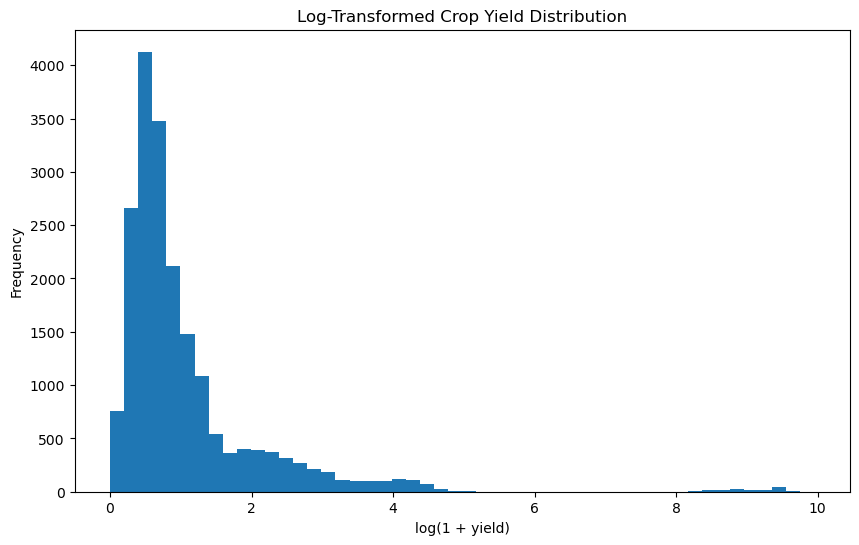

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    model_df["log_yield"],
    bins=50
)

plt.xlabel("log(1 + yield)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Crop Yield Distribution")

plt.show()

In [38]:
print(
    model_df.groupby("year")["yield"]
    .agg(["count", "mean", "median"])
    .to_string()
)

      count        mean    median
year                             
1997    410   63.872577  0.947857
1998    646   55.938462  0.978115
1999    650   76.943722  0.999792
2000    772   75.572901  0.913352
2001    750   75.441594  0.925570
2002    815   80.656215  0.880000
2003    801   83.694593  1.000000
2004    787   81.201928  0.938939
2005    811   86.486543  0.972308
2006    823   77.479036  0.973571
2007    828   76.749776  0.999545
2008    847   85.636898  1.023333
2009    865   85.949719  0.965000
2010    859   72.177623  1.021250
2011    907   84.045009  1.037273
2012    894   76.564190  1.112308
2013    976   94.867996  1.163750
2014    965  107.150319  1.147143
2015    998   82.242225  1.084692
2016   1036   78.050312  1.129444
2017   1070   74.749449  1.174375
2018   1063   75.253703  1.170714
2019   1079   74.319618  1.175833
2020     37    4.420096  1.120769


In [39]:
# ============================================================
# CELL 66 — FINAL MODEL DATASET
# ============================================================

prediction_features = [
    "crop",
    "year",
    "season",
    "state",
    "area",
    "fertilizer",
    "pesticide",
    "N",
    "P",
    "K",
    "pH",
    "avg_temp_c",
    "total_rainfall_mm",
    "avg_humidity_percent"
]

target = "yield"

model_df = merged_df[
    prediction_features + [target]
].copy()

print("Model dataset shape:")
print(model_df.shape)

print("\nColumns:")
print(model_df.columns.tolist())

Model dataset shape:
(19689, 15)

Columns:
['crop', 'year', 'season', 'state', 'area', 'fertilizer', 'pesticide', 'N', 'P', 'K', 'pH', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent', 'yield']


In [40]:

numeric_features = [
    "year",
    "area",
    "fertilizer",
    "pesticide",
    "N",
    "P",
    "K",
    "pH",
    "avg_temp_c",
    "total_rainfall_mm",
    "avg_humidity_percent"
]

for col in numeric_features:
    model_df[col] = pd.to_numeric(
        model_df[col],
        errors="coerce"
    )

print("Missing values:")
print(model_df.isnull().sum())

Missing values:
crop                    0
year                    0
season                  0
state                   0
area                    0
fertilizer              0
pesticide               0
N                       0
P                       0
K                       0
pH                      0
avg_temp_c              0
total_rainfall_mm       0
avg_humidity_percent    0
yield                   0
dtype: int64


In [41]:

categorical_features = [
    "crop",
    "season",
    "state"
]

for col in categorical_features:
    model_df[col] = (
        model_df[col]
        .astype(str)
        .str.strip()
    )

print("Unique categorical values:")
for col in categorical_features:
    print(f"\n{col}: {model_df[col].nunique()}")

Unique categorical values:

crop: 55

season: 6

state: 30


In [42]:

before = len(model_df)

model_df = model_df[
    model_df["yield"].notna()
]

model_df = model_df[
    model_df["yield"] >= 0
]

after = len(model_df)

print("Rows before:", before)
print("Rows after :", after)
print("Rows removed:", before - after)

Rows before: 19689
Rows after : 19689
Rows removed: 0


In [43]:

model_df["log_yield"] = np.log1p(model_df["yield"])

print(model_df[["yield", "log_yield"]].describe())

              yield     log_yield
count  19689.000000  19689.000000
mean      79.954009      1.081109
std      878.306193      1.135903
min        0.000000      0.000000
25%        0.600000      0.470004
50%        1.030000      0.708036
75%        2.388889      1.220502
max    21105.000000      9.957313


In [44]:


X = model_df[prediction_features].copy()

y = model_df["log_yield"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nX columns:")
print(X.columns.tolist())

X shape: (19689, 14)
y shape: (19689,)

X columns:
['crop', 'year', 'season', 'state', 'area', 'fertilizer', 'pesticide', 'N', 'P', 'K', 'pH', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent']


In [45]:


year_counts = (
    model_df["year"]
    .value_counts()
    .sort_index()
)

print(year_counts)

year
1997     410
1998     646
1999     650
2000     772
2001     750
2002     815
2003     801
2004     787
2005     811
2006     823
2007     828
2008     847
2009     865
2010     859
2011     907
2012     894
2013     976
2014     965
2015     998
2016    1036
2017    1070
2018    1063
2019    1079
2020      37
Name: count, dtype: int64


In [46]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=X["crop"]
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 15751
Testing samples : 3938


In [47]:


from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "crop",
    "season",
    "state"
]

numeric_features = [
    "year",
    "area",
    "fertilizer",
    "pesticide",
    "N",
    "P",
    "K",
    "pH",
    "avg_temp_c",
    "total_rainfall_mm",
    "avg_humidity_percent"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [48]:


from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_model = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [49]:

print("Training Random Forest...")

rf_pipeline.fit(
    X_train,
    y_train
)

print("Training completed.")

Training Random Forest...
Training completed.


In [50]:

y_pred_log = rf_pipeline.predict(X_test)

# Convert log predictions back to original yield scale
y_pred = np.expm1(y_pred_log)

# Prevent tiny negative floating-point values
y_pred = np.maximum(y_pred, 0)

print("Predictions generated.")

print("\nFirst 10 predictions:")
print(y_pred[:10])

Predictions generated.

First 10 predictions:
[ 0.82071502  0.55939545  1.2946979   1.54333331 14.60153985  1.19981292
  0.2255636   2.78044127  0.63601009  0.72533256]


In [51]:


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

y_test_original = np.expm1(y_test)

mae = mean_absolute_error(
    y_test_original,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        y_pred
    )
)

r2 = r2_score(
    y_test_original,
    y_pred
)

print("=" * 60)
print("RANDOM FOREST RESULTS")
print("=" * 60)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

RANDOM FOREST RESULTS
MAE  : 32.4258
RMSE : 538.1218
R²   : 0.6184


In [52]:
  # ============================================================
# CELL 79 — LOG SCALE EVALUATION
# ============================================================

log_mae = mean_absolute_error(
    y_test,
    y_pred_log
)

log_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_log
    )
)

log_r2 = r2_score(
    y_test,
    y_pred_log
)

print("=" * 60)
print("LOG-SCALE RESULTS")
print("=" * 60)

print(f"Log MAE  : {log_mae:.4f}")
print(f"Log RMSE : {log_rmse:.4f}")
print(f"Log R²   : {log_r2:.4f}")

LOG-SCALE RESULTS
Log MAE  : 0.1431
Log RMSE : 0.2844
Log R²   : 0.9365


In [53]:
# ============================================================
# CELL 80 — ACTUAL VS PREDICTED
# ============================================================

comparison_df = X_test.copy()

comparison_df["actual_yield"] = y_test_original.values
comparison_df["predicted_yield"] = y_pred

comparison_df["absolute_error"] = (
    comparison_df["actual_yield"]
    - comparison_df["predicted_yield"]
).abs()

comparison_df = comparison_df.sort_values(
    "absolute_error",
    ascending=False
)

comparison_df.head(20)

,crop,year,season,state,area,fertilizer,pesticide,N,P,K,pH,avg_temp_c,total_rainfall_mm,avg_humidity_percent,actual_yield,predicted_yield,absolute_error
13962,Coconut,2014,Whole Year,Telangana,439.0,6.627144e+04,144.87,77,48,24,7.0,26.08,638.05,59.27,21105.000000,34.231066,21070.768934
13406,Coconut,2013,Whole Year,Telangana,428.0,6.184172e+04,115.56,77,48,24,7.0,25.50,1008.16,64.90,16254.000000,44.244627,16209.755373
3052,Coconut,2009,Whole Year,Tamil Nadu,400466.0,6.240061e+07,68079.22,80,38,30,6.6,28.22,1165.21,70.58,14134.659350,4184.586956,9950.072394
2166,Coconut,2006,Whole Year,Tamil Nadu,374604.0,4.784068e+07,82412.88,80,38,30,6.6,27.82,1236.69,72.14,13584.691380,5230.863596,8353.827784
3572,Coconut,2011,Whole Year,Tamil Nadu,419400.0,7.025789e+07,138402.00,80,38,30,6.6,27.72,1371.22,72.46,13248.162260,6671.725015,6576.437245
422,Coconut,1999,Whole Year,Puducherry,2214.0,2.349718e+05,597.78,88,55,40,7.0,27.74,923.63,75.11,12812.447500,7095.101779,5717.345721
18015,Coconut,2012,Whole Year,Puducherry,1564.0,2.358512e+05,484.84,88,55,40,7.0,28.05,945.70,74.75,14410.516670,8749.669347,5660.847323
1873,Coconut,2005,Whole Year,Tamil Nadu,370515.0,4.443216e+07,77808.15,80,38,30,6.6,27.90,1894.66,73.91,11777.931720,7107.120214,4670.811506
2612,Coconut,2008,Whole Year,Karnataka,418581.0,5.987383e+07,37672.29,72,42,25,6.9,22.75,1131.17,72.77,6801.366552,2365.732538,4435.634014
4929,Coconut,2016,Whole Year,Karnataka,437099.0,6.698542e+07,152984.65,72,42,25,6.9,24.49,586.82,61.99,7996.762143,3664.439617,4332.322526


In [54]:
# ============================================================
# CELL 81 — PERFORMANCE BY CROP
# ============================================================

comparison_df["crop"] = X_test["crop"].values

crop_results = []

for crop_name, group in comparison_df.groupby("crop"):

    actual = group["actual_yield"]
    predicted = group["predicted_yield"]

    crop_mae = mean_absolute_error(
        actual,
        predicted
    )

    crop_rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    if len(group) >= 2:
        crop_r2 = r2_score(
            actual,
            predicted
        )
    else:
        crop_r2 = np.nan

    crop_results.append({
        "crop": crop_name,
        "samples": len(group),
        "MAE": crop_mae,
        "RMSE": crop_rmse,
        "R2": crop_r2
    })

crop_results_df = pd.DataFrame(
    crop_results
)

crop_results_df.sort_values(
    "MAE",
    ascending=False
)

,crop,samples,MAE,RMSE,R2
5,Black pepper,25,863.406330,4215.339168,0.037096
30,Oilseeds total,6,373.027500,913.385754,0.851348
54,other oilseeds,25,173.649806,866.464798,0.693921
49,Tapioca,40,164.974662,1039.826932,0.747172
38,Ragi,100,157.619234,1147.574328,0.630571
27,Moong(Green Gram),148,140.269750,1378.996432,0.384522
12,Cowpea(Lobia),27,110.392033,568.779338,0.847129
19,Horse-gram,74,88.637020,661.517664,0.852907
20,Jowar,103,82.370263,823.137234,0.617915
48,Sweet potato,54,64.530969,468.422405,0.736010


# ExtraTreesRegressor

In [55]:
# ============================================================
# CELL 82 — EXTRA TREES BASELINE
# ============================================================

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline

extra_model = ExtraTreesRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

extra_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", extra_model)
    ]
)

print("Extra Trees pipeline created.")

Extra Trees pipeline created.


In [56]:
# ============================================================
# CELL 83 — TRAIN EXTRA TREES
# ============================================================

print("Training Extra Trees...")

extra_pipeline.fit(
    X_train,
    y_train
)

print("Extra Trees training completed.")

Training Extra Trees...
Extra Trees training completed.


In [57]:
# ============================================================
# CELL 84 — EXTRA TREES PREDICTIONS
# ============================================================

extra_pred_log = extra_pipeline.predict(X_test)

extra_pred = np.expm1(extra_pred_log)

extra_pred = np.maximum(
    extra_pred,
    0
)

print("Predictions generated.")

print("\nFirst 10 Extra Trees predictions:")
print(extra_pred[:10])

Predictions generated.

First 10 Extra Trees predictions:
[ 0.61877777  0.53928569  1.69293498  2.09532247 20.78765362  1.26160853
  0.22279956  3.42904414  0.60044026  0.34357031]


In [58]:
# ============================================================
# CELL 85 — EXTRA TREES ORIGINAL-SCALE RESULTS
# ============================================================

extra_mae = mean_absolute_error(
    y_test_original,
    extra_pred
)

extra_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        extra_pred
    )
)

extra_r2 = r2_score(
    y_test_original,
    extra_pred
)

print("=" * 60)
print("EXTRA TREES RESULTS")
print("=" * 60)

print(f"MAE  : {extra_mae:.4f}")
print(f"RMSE : {extra_rmse:.4f}")
print(f"R²   : {extra_r2:.4f}")

EXTRA TREES RESULTS
MAE  : 11.4008
RMSE : 238.6875
R²   : 0.9249


In [59]:
# ============================================================
# CELL 86 — EXTRA TREES LOG-SCALE RESULTS
# ============================================================

extra_log_mae = mean_absolute_error(
    y_test,
    extra_pred_log
)

extra_log_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        extra_pred_log
    )
)

extra_log_r2 = r2_score(
    y_test,
    extra_pred_log
)

print("=" * 60)
print("EXTRA TREES LOG-SCALE RESULTS")
print("=" * 60)

print(f"Log MAE  : {extra_log_mae:.4f}")
print(f"Log RMSE : {extra_log_rmse:.4f}")
print(f"Log R²   : {extra_log_r2:.4f}")

EXTRA TREES LOG-SCALE RESULTS
Log MAE  : 0.0904
Log RMSE : 0.2015
Log R²   : 0.9681


In [60]:
# ============================================================
# CELL 87 — EXTRA TREES WORST PREDICTIONS
# ============================================================

extra_comparison_df = X_test.copy()

extra_comparison_df["actual_yield"] = (
    y_test_original.values
)

extra_comparison_df["predicted_yield"] = (
    extra_pred
)

extra_comparison_df["absolute_error"] = (
    extra_comparison_df["actual_yield"]
    - extra_comparison_df["predicted_yield"]
).abs()

extra_comparison_df = (
    extra_comparison_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
)

print(
    extra_comparison_df.head(20).to_string()
)

            crop  year      season           state       area    fertilizer    pesticide   N   P   K   pH  avg_temp_c  total_rainfall_mm  avg_humidity_percent  actual_yield  predicted_yield  absolute_error
13962    Coconut  2014  Whole Year       Telangana     439.00  6.627144e+04     144.8700  77  48  24  7.0       26.08             638.05                 59.27  21105.000000      9973.379234    11131.620766
13406    Coconut  2013  Whole Year       Telangana     428.00  6.184172e+04     115.5600  77  48  24  7.0       25.50            1008.16                 64.90  16254.000000      9682.744876     6571.255124
18015    Coconut  2012  Whole Year      Puducherry    1564.00  2.358512e+05     484.8400  88  55  40  7.0       28.05             945.70                 74.75  14410.516670     10257.236354     4153.280316
3052     Coconut  2009  Whole Year      Tamil Nadu  400466.00  6.240061e+07   68079.2200  80  38  30  6.6       28.22            1165.21                 70.58  14134.659350    

In [61]:
# ============================================================
# CELL 88 — EXTRA TREES PERFORMANCE BY CROP
# ============================================================

extra_crop_results = []

for crop_name, group in (
    extra_comparison_df.groupby("crop")
):

    actual = group["actual_yield"]
    predicted = group["predicted_yield"]

    crop_mae = mean_absolute_error(
        actual,
        predicted
    )

    crop_rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    if len(group) >= 2:
        crop_r2 = r2_score(
            actual,
            predicted
        )
    else:
        crop_r2 = np.nan

    extra_crop_results.append({
        "crop": crop_name,
        "samples": len(group),
        "MAE": crop_mae,
        "RMSE": crop_rmse,
        "R2": crop_r2
    })

extra_crop_results_df = pd.DataFrame(
    extra_crop_results
)

print(
    extra_crop_results_df
    .sort_values(
        "MAE",
        ascending=False
    )
    .to_string(index=False)
)

                 crop  samples         MAE        RMSE        R2
              Coconut       34 1224.050497 2566.936701  0.696824
            Cashewnut       27   12.683365   65.071032 -0.039284
                Onion       91    5.707550   36.613943  0.131807
            Sugarcane      121    5.335148    8.312736  0.922071
               Banana       49    4.098421    9.587264  0.818360
               Potato      126    3.821784   23.142604  0.279474
              Tapioca       40    2.095963    3.508937  0.912025
               Ginger       65    1.949451    4.203501  0.655408
         Sweet potato       54    1.239326    2.058468  0.854227
                Mesta       42    1.072945    1.760845  0.756353
              Tobacco       73    1.020910    6.207181  0.122920
                 Jute       36    1.000712    1.583049  0.877333
               Garlic       50    0.654089    1.122057  0.924751
                Maize      195    0.566240    1.678789  0.712106
         Dry chillies    

# HistGradientBoosting model training 

In [62]:
# Copy the existing train/test data
X_train_hgb = X_train.copy()
X_test_hgb = X_test.copy()

y_train_hgb = y_train.copy()
y_test_hgb = y_test.copy()

print("HGB training shape:", X_train_hgb.shape)
print("HGB testing shape :", X_test_hgb.shape)

print("\nColumns:")
print(X_train_hgb.columns.tolist())

HGB training shape: (15751, 14)
HGB testing shape : (3938, 14)

Columns:
['crop', 'year', 'season', 'state', 'area', 'fertilizer', 'pesticide', 'N', 'P', 'K', 'pH', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent']


In [63]:
# ============================================================
# CELL 90 — CONVERT CATEGORICAL FEATURES
# ============================================================

categorical_columns = [
    "crop",
    "season",
    "state"
]

for column in categorical_columns:

    # Use the combined dataset so train/test
    # have the same category definitions
    combined = pd.concat(
        [
            X_train_hgb[column],
            X_test_hgb[column]
        ]
    ).astype("category")

    categories = combined.cat.categories

    X_train_hgb[column] = (
        pd.Categorical(
            X_train_hgb[column],
            categories=categories
        )
    )

    X_test_hgb[column] = (
        pd.Categorical(
            X_test_hgb[column],
            categories=categories
        )
    )

print("Categorical columns:")
for column in categorical_columns:
    print(
        column,
        "->",
        X_train_hgb[column].dtype
    )

Categorical columns:
crop -> category
season -> category
state -> category


In [64]:
# ============================================================
# CELL 91 — CHECK CATEGORICAL CARDINALITY
# ============================================================

print("=" * 60)
print("CATEGORICAL FEATURE CARDINALITY")
print("=" * 60)

for column in categorical_columns:

    unique_count = (
        X_train_hgb[column]
        .nunique()
    )

    print(
        f"{column}: {unique_count} categories"
    )

CATEGORICAL FEATURE CARDINALITY
crop: 55 categories
season: 6 categories
state: 30 categories


In [65]:
# ============================================================
# CELL 92 — CREATE HISTGRADIENTBOOSTING MODEL
# ============================================================

from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model = HistGradientBoostingRegressor(
    loss="squared_error",

    learning_rate=0.05,

    max_iter=500,

    max_leaf_nodes=31,

    max_depth=None,

    min_samples_leaf=20,

    l2_regularization=1.0,

    max_features=1.0,

    categorical_features="from_dtype",

    early_stopping=True,

    validation_fraction=0.1,

    n_iter_no_change=30,

    random_state=42
)

print("HistGradientBoostingRegressor created.")

HistGradientBoostingRegressor created.


In [66]:
# ============================================================
# CELL 93 — TRAIN HISTGRADIENTBOOSTING
# ============================================================

print("=" * 60)
print("TRAINING HISTGRADIENTBOOSTING")
print("=" * 60)

hgb_model.fit(
    X_train_hgb,
    y_train_hgb
)

print("\nTraining completed.")

print(
    "\nNumber of boosting iterations used:",
    hgb_model.n_iter_
)

TRAINING HISTGRADIENTBOOSTING

Training completed.

Number of boosting iterations used: 500


In [67]:
# ============================================================
# CELL 94 — HGB PREDICTIONS
# ============================================================

hgb_pred_log = hgb_model.predict(
    X_test_hgb
)

hgb_pred = np.expm1(
    hgb_pred_log
)

# Yield cannot be negative
hgb_pred = np.maximum(
    hgb_pred,
    0
)

print("Predictions generated.")

print("\nFirst 10 HGB predictions:")
print(hgb_pred[:10])

Predictions generated.

First 10 HGB predictions:
[ 0.51876493  0.59351197  1.49052188  1.77833791 20.78021375  1.24217261
  0.17014574  3.37422106  0.54765099  0.50131516]


In [68]:
# ============================================================
# CELL 95 — HGB ORIGINAL-SCALE RESULTS
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

hgb_mae = mean_absolute_error(
    y_test_original,
    hgb_pred
)

hgb_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        hgb_pred
    )
)

hgb_r2 = r2_score(
    y_test_original,
    hgb_pred
)

print("=" * 60)
print("HISTGRADIENTBOOSTING RESULTS")
print("=" * 60)

print(f"MAE  : {hgb_mae:.4f}")
print(f"RMSE : {hgb_rmse:.4f}")
print(f"R²   : {hgb_r2:.4f}")

HISTGRADIENTBOOSTING RESULTS
MAE  : 18.7862
RMSE : 429.8950
R²   : 0.7565


In [69]:
# ============================================================
# CELL 96 — HGB LOG-SCALE RESULTS
# ============================================================

hgb_log_mae = mean_absolute_error(
    y_test_hgb,
    hgb_pred_log
)

hgb_log_rmse = np.sqrt(
    mean_squared_error(
        y_test_hgb,
        hgb_pred_log
    )
)

hgb_log_r2 = r2_score(
    y_test_hgb,
    hgb_pred_log
)

print("=" * 60)
print("HISTGRADIENTBOOSTING LOG-SCALE RESULTS")
print("=" * 60)

print(f"Log MAE  : {hgb_log_mae:.4f}")
print(f"Log RMSE : {hgb_log_rmse:.4f}")
print(f"Log R²   : {hgb_log_r2:.4f}")

HISTGRADIENTBOOSTING LOG-SCALE RESULTS
Log MAE  : 0.1214
Log RMSE : 0.2372
Log R²   : 0.9558


In [70]:
# ============================================================
# CELL 97 — MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Extra Trees",
        "HistGradientBoosting"
    ],

    "MAE": [
        32.4258,
        11.4008,
        hgb_mae
    ],

    "RMSE": [
        538.1218,
        238.6875,
        hgb_rmse
    ],

    "R2": [
        0.6184,
        0.9249,
        hgb_r2
    ],

    "Log MAE": [
        0.1431,
        0.0904,
        hgb_log_mae
    ],

    "Log RMSE": [
        0.2844,
        0.2015,
        hgb_log_rmse
    ],

    "Log R2": [
        0.9365,
        0.9681,
        hgb_log_r2
    ]
})

print(
    model_comparison.to_string(
        index=False
    )
)

               Model       MAE       RMSE       R2  Log MAE  Log RMSE   Log R2
       Random Forest 32.425800 538.121800 0.618400 0.143100  0.284400 0.936500
         Extra Trees 11.400800 238.687500 0.924900 0.090400  0.201500 0.968100
HistGradientBoosting 18.786188 429.894964 0.756477 0.121406  0.237232 0.955834


In [71]:
# ============================================================
# CELL 98 — HGB WORST PREDICTIONS
# ============================================================

hgb_comparison_df = X_test_hgb.copy()

hgb_comparison_df["actual_yield"] = (
    y_test_original.values
)

hgb_comparison_df["predicted_yield"] = (
    hgb_pred
)

hgb_comparison_df["absolute_error"] = (
    hgb_comparison_df["actual_yield"]
    - hgb_comparison_df["predicted_yield"]
).abs()

hgb_comparison_df = (
    hgb_comparison_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
)

print(
    hgb_comparison_df.head(20).to_string()
)

          crop  year      season        state       area    fertilizer    pesticide   N   P   K   pH  avg_temp_c  total_rainfall_mm  avg_humidity_percent  actual_yield  predicted_yield  absolute_error
13962  Coconut  2014  Whole Year    Telangana     439.00  6.627144e+04     144.8700  77  48  24  7.0       26.08             638.05                 59.27  21105.000000       817.980068    20287.019932
13406  Coconut  2013  Whole Year    Telangana     428.00  6.184172e+04     115.5600  77  48  24  7.0       25.50            1008.16                 64.90  16254.000000       779.982539    15474.017461
18015  Coconut  2012  Whole Year   Puducherry    1564.00  2.358512e+05     484.8400  88  55  40  7.0       28.05             945.70                 74.75  14410.516670     10876.390549     3534.126121
3052   Coconut  2009  Whole Year   Tamil Nadu  400466.00  6.240061e+07   68079.2200  80  38  30  6.6       28.22            1165.21                 70.58  14134.659350     10715.830556     3418.82

In [72]:
# ============================================================
# CELL 99 — HGB COCONUT PERFORMANCE
# ============================================================

hgb_coconut_df = hgb_comparison_df[
    hgb_comparison_df["crop"] == "Coconut"
].copy()

hgb_coconut_mae = mean_absolute_error(
    hgb_coconut_df["actual_yield"],
    hgb_coconut_df["predicted_yield"]
)

hgb_coconut_rmse = np.sqrt(
    mean_squared_error(
        hgb_coconut_df["actual_yield"],
        hgb_coconut_df["predicted_yield"]
    )
)

hgb_coconut_r2 = r2_score(
    hgb_coconut_df["actual_yield"],
    hgb_coconut_df["predicted_yield"]
)

print("=" * 60)
print("HISTGRADIENTBOOSTING — COCONUT")
print("=" * 60)

print(
    f"Samples: {len(hgb_coconut_df)}"
)

print(
    f"MAE    : {hgb_coconut_mae:.4f}"
)

print(
    f"RMSE   : {hgb_coconut_rmse:.4f}"
)

print(
    f"R²     : {hgb_coconut_r2:.4f}"
)

HISTGRADIENTBOOSTING — COCONUT
Samples: 34
MAE    : 2062.4086
RMSE   : 4625.5040
R²     : 0.0156


In [73]:
# ============================================================
# CELL 100 — HGB PERFORMANCE BY CROP
# ============================================================

hgb_crop_results = []

for crop_name, group in (
    hgb_comparison_df.groupby("crop")
):

    actual = group["actual_yield"]
    predicted = group["predicted_yield"]

    crop_mae = mean_absolute_error(
        actual,
        predicted
    )

    crop_rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    if len(group) >= 2:
        crop_r2 = r2_score(
            actual,
            predicted
        )
    else:
        crop_r2 = np.nan

    hgb_crop_results.append({

        "crop": crop_name,

        "samples": len(group),

        "MAE": crop_mae,

        "RMSE": crop_rmse,

        "R2": crop_r2
    })

hgb_crop_results_df = pd.DataFrame(
    hgb_crop_results
)

hgb_crop_results_df = (
    hgb_crop_results_df
    .sort_values(
        "MAE",
        ascending=False
    )
)

print(
    hgb_crop_results_df.to_string(
        index=False
    )
)

                 crop  samples         MAE        RMSE        R2
              Coconut       34 2062.408556 4625.503952  0.015576
            Cashewnut       27   12.717825   65.084245 -0.039706
                Onion       91    6.248098   37.343960  0.096842
            Sugarcane      121    5.948082    8.383971  0.920730
               Banana       49    4.970005   11.452953  0.740787
               Potato      126    4.368475   24.700521  0.179200
              Tapioca       40    2.333231    3.331602  0.920692
               Ginger       65    2.218496    4.601756  0.587020
                 Jute       36    2.172206    2.888385  0.591636
         Sweet potato       54    1.826398    2.745180  0.740743
                Mesta       42    1.214834    1.975476  0.693336
              Tobacco       73    1.138899    6.208581  0.122524
               Garlic       50    0.932867    1.492196  0.866917
             Turmeric       67    0.897229    2.091575  0.617236
       other oilseeds    

In [74]:
# ============================================================
# CELL 101 — COCONUT MODEL COMPARISON
# ============================================================

extra_coconut_df = extra_comparison_df[
    extra_comparison_df["crop"] == "Coconut"
].copy()

extra_coconut_mae = mean_absolute_error(
    extra_coconut_df["actual_yield"],
    extra_coconut_df["predicted_yield"]
)

extra_coconut_rmse = np.sqrt(
    mean_squared_error(
        extra_coconut_df["actual_yield"],
        extra_coconut_df["predicted_yield"]
    )
)

extra_coconut_r2 = r2_score(
    extra_coconut_df["actual_yield"],
    extra_coconut_df["predicted_yield"]
)

coconut_comparison = pd.DataFrame({

    "Model": [
        "Extra Trees",
        "HistGradientBoosting"
    ],

    "MAE": [
        extra_coconut_mae,
        hgb_coconut_mae
    ],

    "RMSE": [
        extra_coconut_rmse,
        hgb_coconut_rmse
    ],

    "R2": [
        extra_coconut_r2,
        hgb_coconut_r2
    ]
})

print(
    coconut_comparison.to_string(
        index=False
    )
)

               Model         MAE        RMSE       R2
         Extra Trees 1224.050497 2566.936701 0.696824
HistGradientBoosting 2062.408556 4625.503952 0.015576


# trainig xg boost model 

In [75]:
# ============================================================
# CELL 102 — CHECK XGBOOST
# ============================================================

import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.3.0


In [76]:
# ============================================================
# CELL 103 — PREPARE DATA FOR XGBOOST
# ============================================================

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

y_train_xgb = y_train.copy()
y_test_xgb = y_test.copy()

print("Training shape:", X_train_xgb.shape)
print("Testing shape :", X_test_xgb.shape)

Training shape: (15751, 14)
Testing shape : (3938, 14)


In [77]:
# ============================================================
# CELL 104 — ONE-HOT ENCODE CATEGORICAL FEATURES
# ============================================================

categorical_columns = [
    "crop",
    "season",
    "state"
]

X_train_xgb = pd.get_dummies(
    X_train_xgb,
    columns=categorical_columns,
    dtype=float
)

X_test_xgb = pd.get_dummies(
    X_test_xgb,
    columns=categorical_columns,
    dtype=float
)

# Make sure train and test have exactly the same columns
X_test_xgb = X_test_xgb.reindex(
    columns=X_train_xgb.columns,
    fill_value=0
)

print("Encoded training shape:", X_train_xgb.shape)
print("Encoded testing shape :", X_test_xgb.shape)

Encoded training shape: (15751, 102)
Encoded testing shape : (3938, 102)


In [78]:
# ============================================================
# CELL 105 — ENSURE NUMERIC DATA
# ============================================================

X_train_xgb = X_train_xgb.astype(np.float32)
X_test_xgb = X_test_xgb.astype(np.float32)

y_train_xgb = np.asarray(
    y_train_xgb,
    dtype=np.float32
)

y_test_xgb = np.asarray(
    y_test_xgb,
    dtype=np.float32
)

print("Data ready for XGBoost.")

Data ready for XGBoost.


In [79]:
# ============================================================
# CELL 106 — CREATE XGBOOST REGRESSOR
# ============================================================

from xgboost import XGBRegressor

xgb_model = XGBRegressor(

    objective="reg:squarederror",

    n_estimators=1000,

    learning_rate=0.03,

    max_depth=6,

    min_child_weight=3,

    subsample=0.8,

    colsample_bytree=0.8,

    reg_alpha=0.0,

    reg_lambda=1.0,

    gamma=0.0,

    tree_method="hist",

    random_state=42,

    n_jobs=-1
)

print("XGBoost model created.")

XGBoost model created.


In [80]:
# ============================================================
# CELL 107 — TRAIN XGBOOST
# ============================================================

print("=" * 60)
print("TRAINING XGBOOST")
print("=" * 60)

xgb_model.fit(
    X_train_xgb,
    y_train_xgb,
    verbose=False
)

print("\nTraining completed.")

TRAINING XGBOOST

Training completed.


In [81]:
# ============================================================
# CELL 108 — XGBOOST PREDICTIONS
# ============================================================

xgb_pred_log = xgb_model.predict(
    X_test_xgb
)

xgb_pred = np.expm1(
    xgb_pred_log
)

# Prevent negative yields
xgb_pred = np.maximum(
    xgb_pred,
    0
)

print("Predictions generated.")

print("\nFirst 10 XGBoost predictions:")
print(xgb_pred[:10])

Predictions generated.

First 10 XGBoost predictions:
[ 0.6862788   0.4396316   1.1875503   1.3744864  18.522835    1.244437
  0.22482859  2.9338713   0.5104196   0.79688215]


In [82]:
# ============================================================
# CELL 109 — XGBOOST RESULTS
# ============================================================

xgb_mae = mean_absolute_error(
    y_test_original,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        xgb_pred
    )
)

xgb_r2 = r2_score(
    y_test_original,
    xgb_pred
)

print("=" * 60)
print("XGBOOST RESULTS")
print("=" * 60)

print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")

XGBOOST RESULTS
MAE  : 17.0412
RMSE : 372.6198
R²   : 0.8170


In [83]:
# ============================================================
# CELL 110 — XGBOOST LOG-SCALE RESULTS
# ============================================================

xgb_log_mae = mean_absolute_error(
    y_test_xgb,
    xgb_pred_log
)

xgb_log_rmse = np.sqrt(
    mean_squared_error(
        y_test_xgb,
        xgb_pred_log
    )
)

xgb_log_r2 = r2_score(
    y_test_xgb,
    xgb_pred_log
)

print("=" * 60)
print("XGBOOST LOG-SCALE RESULTS")
print("=" * 60)

print(f"Log MAE  : {xgb_log_mae:.4f}")
print(f"Log RMSE : {xgb_log_rmse:.4f}")
print(f"Log R²   : {xgb_log_r2:.4f}")

XGBOOST LOG-SCALE RESULTS
Log MAE  : 0.1333
Log RMSE : 0.2364
Log R²   : 0.9561


In [84]:
# ============================================================
# CELL 111 — COMPLETE MODEL COMPARISON
# ============================================================

model_comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Extra Trees",
        "HistGradientBoosting",
        "XGBoost"
    ],

    "MAE": [
        32.4258,
        11.4008,
        18.7862,
        xgb_mae
    ],

    "RMSE": [
        538.1218,
        238.6875,
        429.8950,
        xgb_rmse
    ],

    "R2": [
        0.6184,
        0.9249,
        0.7565,
        xgb_r2
    ],

    "Log MAE": [
        0.1431,
        0.0904,
        0.1214,
        xgb_log_mae
    ],

    "Log RMSE": [
        0.2844,
        0.2015,
        0.2372,
        xgb_log_rmse
    ],

    "Log R2": [
        0.9365,
        0.9681,
        0.9558,
        xgb_log_r2
    ]
})

print(
    model_comparison.to_string(
        index=False
    )
)

               Model       MAE       RMSE       R2  Log MAE  Log RMSE   Log R2
       Random Forest 32.425800 538.121800 0.618400  0.14310  0.284400 0.936500
         Extra Trees 11.400800 238.687500 0.924900  0.09040  0.201500 0.968100
HistGradientBoosting 18.786200 429.895000 0.756500  0.12140  0.237200 0.955800
             XGBoost 17.041157 372.619785 0.817044  0.13325  0.236438 0.956129


In [85]:
# ============================================================
# CELL 112 — XGBOOST WORST PREDICTIONS
# ============================================================

xgb_comparison_df = X_test.copy()

xgb_comparison_df["actual_yield"] = (
    y_test_original.values
)

xgb_comparison_df["predicted_yield"] = (
    xgb_pred
)

xgb_comparison_df["absolute_error"] = (
    xgb_comparison_df["actual_yield"]
    - xgb_comparison_df["predicted_yield"]
).abs()

xgb_comparison_df = (
    xgb_comparison_df
    .sort_values(
        "absolute_error",
        ascending=False
    )
)

print(
    xgb_comparison_df.head(20).to_string()
)

          crop  year      season        state       area    fertilizer    pesticide   N   P   K   pH  avg_temp_c  total_rainfall_mm  avg_humidity_percent  actual_yield  predicted_yield  absolute_error
13962  Coconut  2014  Whole Year    Telangana     439.00  6.627144e+04     144.8700  77  48  24  7.0       26.08             638.05                 59.27  21105.000000      3709.039062    17395.960938
13406  Coconut  2013  Whole Year    Telangana     428.00  6.184172e+04     115.5600  77  48  24  7.0       25.50            1008.16                 64.90  16254.000000      4296.970215    11957.029785
2166   Coconut  2006  Whole Year   Tamil Nadu  374604.00  4.784068e+07   82412.8800  80  38  30  6.6       27.82            1236.69                 72.14  13584.691380      8136.677246     5448.014134
3052   Coconut  2009  Whole Year   Tamil Nadu  400466.00  6.240061e+07   68079.2200  80  38  30  6.6       28.22            1165.21                 70.58  14134.659350      9339.941406     4794.71

In [86]:
# ============================================================
# CELL 113 — XGBOOST COCONUT PERFORMANCE
# ============================================================

xgb_coconut_df = xgb_comparison_df[
    xgb_comparison_df["crop"] == "Coconut"
].copy()

xgb_coconut_mae = mean_absolute_error(
    xgb_coconut_df["actual_yield"],
    xgb_coconut_df["predicted_yield"]
)

xgb_coconut_rmse = np.sqrt(
    mean_squared_error(
        xgb_coconut_df["actual_yield"],
        xgb_coconut_df["predicted_yield"]
    )
)

xgb_coconut_r2 = r2_score(
    xgb_coconut_df["actual_yield"],
    xgb_coconut_df["predicted_yield"]
)

print("=" * 60)
print("XGBOOST — COCONUT")
print("=" * 60)

print(f"Samples: {len(xgb_coconut_df)}")
print(f"MAE    : {xgb_coconut_mae:.4f}")
print(f"RMSE   : {xgb_coconut_rmse:.4f}")
print(f"R²     : {xgb_coconut_r2:.4f}")

XGBOOST — COCONUT
Samples: 34
MAE    : 1853.7638
RMSE   : 4008.9550
R²     : 0.2605


In [87]:
# ============================================================
# CELL 114 — XGBOOST PERFORMANCE BY CROP
# ============================================================

xgb_crop_results = []

for crop_name, group in (
    xgb_comparison_df.groupby("crop")
):

    actual = group["actual_yield"]
    predicted = group["predicted_yield"]

    crop_mae = mean_absolute_error(
        actual,
        predicted
    )

    crop_rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    if len(group) >= 2:
        crop_r2 = r2_score(
            actual,
            predicted
        )
    else:
        crop_r2 = np.nan

    xgb_crop_results.append({

        "crop": crop_name,

        "samples": len(group),

        "MAE": crop_mae,

        "RMSE": crop_rmse,

        "R2": crop_r2
    })

xgb_crop_results_df = pd.DataFrame(
    xgb_crop_results
)

xgb_crop_results_df = (
    xgb_crop_results_df
    .sort_values(
        "MAE",
        ascending=False
    )
)

print(
    xgb_crop_results_df.to_string(
        index=False
    )
)

                 crop  samples         MAE        RMSE        R2
              Coconut       34 1853.763813 4008.954996  0.260520
            Cashewnut       27   12.733100   65.090988 -0.039922
                Onion       91    6.408111   36.744975  0.125582
            Sugarcane      121    6.013276    8.926027  0.910148
               Banana       49    5.461197   12.430686  0.694640
               Potato      126    4.403399   23.931152  0.229536
              Tapioca       40    2.530001    3.782501  0.897773
               Ginger       65    2.296268    4.631094  0.581737
         Sweet potato       54    1.954273    3.088280  0.671888
                 Jute       36    1.854861    2.457541  0.704376
                Mesta       42    1.371531    1.883872  0.721117
              Tobacco       73    1.233534    6.310918  0.093359
               Garlic       50    0.983942    1.575228  0.851694
                Maize      195    0.922901    2.586880  0.316415
             Turmeric    

# ============================================================
# Tunning the Extra Trees coz it is the best model so far 
# ============================================================

In [88]:
# ============================================================
# CELL 95 — CHECK TRAINING DATA TYPES
# ============================================================

print("=" * 60)
print("X_train INFORMATION")
print("=" * 60)

print("Shape:", X_train.shape)

print("\nData types:")
print(X_train.dtypes)

print("\nNon-numeric columns:")

non_numeric_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(non_numeric_cols)

print("\nNumber of non-numeric columns:")
print(len(non_numeric_cols))

X_train INFORMATION
Shape: (15751, 14)

Data types:
crop                     object
year                      int64
season                   object
state                    object
area                    float64
fertilizer              float64
pesticide               float64
N                         int64
P                         int64
K                         int64
pH                      float64
avg_temp_c              float64
total_rainfall_mm       float64
avg_humidity_percent    float64
dtype: object

Non-numeric columns:
['crop', 'season', 'state']

Number of non-numeric columns:
3


In [89]:
# ============================================================
# CELL 96 — FIND NUMERIC TRAINING DATA
# ============================================================

print("=" * 60)
print("CHECKING AVAILABLE DATA VARIABLES")
print("=" * 60)

for name in [
    "X_train",
    "X_test",
    "X_train_encoded",
    "X_test_encoded",
    "X_train_processed",
    "X_test_processed",
    "X_train_scaled",
    "X_test_scaled",
    "X_train_final",
    "X_test_final",
]:
    if name in globals():
        obj = globals()[name]

        print(f"\n{name}")
        print("Type:", type(obj))
        
        if hasattr(obj, "shape"):
            print("Shape:", obj.shape)
        
        if isinstance(obj, pd.DataFrame):
            print("Non-numeric columns:",
                  obj.select_dtypes(include=["object", "category"]).columns.tolist())

CHECKING AVAILABLE DATA VARIABLES

X_train
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (15751, 14)
Non-numeric columns: ['crop', 'season', 'state']

X_test
Type: <class 'pandas.core.frame.DataFrame'>
Shape: (3938, 14)
Non-numeric columns: ['crop', 'season', 'state']


In [90]:
# ============================================================
# CELL 99 — FIND PREPROCESSING / ENCODING OBJECTS
# ============================================================

print("=" * 60)
print("SEARCHING FOR PREPROCESSING OBJECTS")
print("=" * 60)

# Make a snapshot so globals() cannot change during iteration
all_variables = list(globals().items())

keywords = [
    "encoder",
    "transform",
    "preprocess",
    "column",
    "pipeline",
    "scaler",
    "onehot",
    "ordinal",
    "model",
    "extra",
    "forest"
]

for name, obj in all_variables:

    if name.startswith("_"):
        continue

    name_lower = name.lower()
    obj_type = type(obj).__name__
    obj_type_lower = obj_type.lower()

    if any(
        keyword in name_lower or keyword in obj_type_lower
        for keyword in keywords
    ):

        print(f"\n{name}")
        print(f"Type: {obj_type}")

        if hasattr(obj, "shape"):
            print(f"Shape: {obj.shape}")

SEARCHING FOR PREPROCESSING OBJECTS

ColumnTransformer
Type: ABCMeta

Pipeline
Type: ABCMeta

OneHotEncoder
Type: type

StandardScaler
Type: type

RandomForestRegressor
Type: ABCMeta

ExtraTreesRegressor
Type: ABCMeta

categoricial_columns
Type: list

column
Type: str

model_df
Type: DataFrame
Shape: (19689, 16)

preprocessor
Type: ColumnTransformer

rf_model
Type: RandomForestRegressor

rf_pipeline
Type: Pipeline

extra_model
Type: ExtraTreesRegressor

extra_pipeline
Type: Pipeline

extra_pred_log
Type: ndarray
Shape: (3938,)

extra_pred
Type: ndarray
Shape: (3938,)

extra_mae
Type: float

extra_rmse
Type: float64
Shape: ()

extra_r2
Type: float

extra_log_mae
Type: float

extra_log_rmse
Type: float64
Shape: ()

extra_log_r2
Type: float

extra_comparison_df
Type: DataFrame
Shape: (3938, 17)

extra_crop_results
Type: list

extra_crop_results_df
Type: DataFrame
Shape: (55, 5)

categorical_columns
Type: list

hgb_model
Type: HistGradientBoostingRegressor

model_comparison
Type: DataFrame

In [91]:
# ============================================================
# CELL 101 — FIND ACTUAL EXTRA TREES MODEL / PIPELINE
# ============================================================

print("=" * 60)
print("CHECKING EXISTING EXTRA TREES OBJECTS")
print("=" * 60)

print("\nextra_model:")
print(type(extra_model))

print("\nextra_pipeline:")
print(type(extra_pipeline))

print("\nextra_model parameters:")
for key, value in extra_model.get_params().items():
    print(f"{key}: {value}")

print("\n" + "=" * 60)
print("EXTRA PIPELINE STEPS")
print("=" * 60)

print(extra_pipeline)

print("\n" + "=" * 60)
print("PREPROCESSOR")
print("=" * 60)

print(preprocessor)

CHECKING EXISTING EXTRA TREES OBJECTS

extra_model:
<class 'sklearn.ensemble._forest.ExtraTreesRegressor'>

extra_pipeline:
<class 'sklearn.pipeline.Pipeline'>

extra_model parameters:
bootstrap: False
ccp_alpha: 0.0
criterion: squared_error
max_depth: None
max_features: 1.0
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 500
n_jobs: -1
oob_score: False
random_state: 42
verbose: 0
warm_start: False

EXTRA PIPELINE STEPS
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['crop', 'season', 'state']),
                                                 ('numeric', 'passthrough',
                                                  ['year', 'area', 'fertilizer',
                            

In [92]:
# ============================================================
# CELL 102 — CREATE ENCODED DATA FROM EXISTING PREPROCESSOR
# ============================================================

print("=" * 60)
print("CREATING ENCODED TRAIN / TEST DATA")
print("=" * 60)

# Use the existing preprocessor
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("\nEncoded training shape:")
print(X_train_encoded.shape)

print("\nEncoded testing shape:")
print(X_test_encoded.shape)

print("\nEncoded data type:")
print(type(X_train_encoded))

CREATING ENCODED TRAIN / TEST DATA

Encoded training shape:
(15751, 102)

Encoded testing shape:
(3938, 102)

Encoded data type:
<class 'scipy.sparse._csr.csr_matrix'>


In [93]:
# ============================================================
# CELL 103 — VERIFY ENCODED DATA
# ============================================================

print("=" * 60)
print("VERIFYING ENCODED DATA")
print("=" * 60)

print("X_train original :", X_train.shape)
print("X_test original  :", X_test.shape)

print("X_train encoded  :", X_train_encoded.shape)
print("X_test encoded   :", X_test_encoded.shape)

print("\nOriginal categorical columns:")
print(categorical_columns)

print("\nEncoding successful.")

VERIFYING ENCODED DATA
X_train original : (15751, 14)
X_test original  : (3938, 14)
X_train encoded  : (15751, 102)
X_test encoded   : (3938, 102)

Original categorical columns:
['crop', 'season', 'state']

Encoding successful.


In [94]:
# ============================================================
# CELL 104 — PREPARE DATA FOR EXTRA TREES TUNING
# ============================================================

X_tune_train = X_train_encoded
X_tune_test = X_test_encoded

y_tune_train = y_train
y_tune_test = y_test

print("=" * 60)
print("TUNING DATA READY")
print("=" * 60)

print("Training X:", X_tune_train.shape)
print("Testing X :", X_tune_test.shape)

print("Training y:", y_tune_train.shape)
print("Testing y :", y_tune_test.shape)

TUNING DATA READY
Training X: (15751, 102)
Testing X : (3938, 102)
Training y: (15751,)
Testing y : (3938,)


# real tuning

In [95]:
# ============================================================
# CELL 105 — FAST EXTRA TREES TUNING
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline

print("=" * 60)
print("FAST TUNING EXTRA TREES")
print("=" * 60)

# ------------------------------------------------------------
# Base model
# ------------------------------------------------------------

et_tune_model = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1,
    criterion="squared_error"
)

# ------------------------------------------------------------
# Pipeline
# ------------------------------------------------------------

et_tune_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", et_tune_model)
])

# ------------------------------------------------------------
# Smaller / faster parameter search
# ------------------------------------------------------------

param_grid = {
    "model__n_estimators": [
        300,
        500,
        700
    ],

    "model__max_depth": [
        None,
        20,
        30,
        40
    ],

    "model__min_samples_split": [
        2,
        5,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__max_features": [
        0.7,
        1.0
    ]
}

# ------------------------------------------------------------
# Randomized search
# ------------------------------------------------------------

et_search = RandomizedSearchCV(
    estimator=et_tune_pipeline,
    param_distributions=param_grid,
    n_iter=12,
    scoring="r2",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

print("\nStarting 12-candidate search...")
print("This will perform 36 total fits.\n")

# ------------------------------------------------------------
# Fit
# ------------------------------------------------------------

et_search.fit(X_train, y_train)

print("\n" + "=" * 60)
print("TUNING COMPLETE")
print("=" * 60)

print("\nBest CV R²:")
print(f"{et_search.best_score_:.6f}")

print("\nBest parameters:")

for key, value in et_search.best_params_.items():
    print(f"{key}: {value}")

FAST TUNING EXTRA TREES

Starting 12-candidate search...
This will perform 36 total fits.

Fitting 3 folds for each of 12 candidates, totalling 36 fits

TUNING COMPLETE

Best CV R²:
0.960673

Best parameters:
model__n_estimators: 300
model__min_samples_split: 5
model__min_samples_leaf: 1
model__max_features: 1.0
model__max_depth: None


In [98]:
# ============================================================
# CELL 105B — VERY FAST EXTRA TREES TUNING
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline

print("=" * 60)
print("VERY FAST EXTRA TREES TUNING")
print("=" * 60)

et_fast_model = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1,
    criterion="squared_error"
)

et_fast_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", et_fast_model)
])

param_grid_fast = {
    "model__n_estimators": [
        400,
        500,
        600
    ],

    "model__max_depth": [
        None,
        30,
        40
    ],

    "model__min_samples_split": [
        2,
        3,
        5
    ],

    "model__min_samples_leaf": [
        1,
        2
    ],

    "model__max_features": [
        0.8,
        1.0
    ]
}

et_search_fast = RandomizedSearchCV(
    estimator=et_fast_pipeline,
    param_distributions=param_grid_fast,
    n_iter=8,
    scoring="r2",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("\nStarting 8 candidates × 3 folds = 24 fits...\n")

et_search_fast.fit(X_train, y_train)

print("\n" + "=" * 60)
print("FAST TUNING COMPLETE")
print("=" * 60)

print("\nBest CV R²:")
print(f"{et_search_fast.best_score_:.6f}")

print("\nBest parameters:")

for key, value in et_search_fast.best_params_.items():
    print(f"{key}: {value}")

VERY FAST EXTRA TREES TUNING

Starting 8 candidates × 3 folds = 24 fits...

Fitting 3 folds for each of 8 candidates, totalling 24 fits

FAST TUNING COMPLETE

Best CV R²:
0.961966

Best parameters:
model__n_estimators: 500
model__min_samples_split: 2
model__min_samples_leaf: 2
model__max_features: 0.8
model__max_depth: None


In [99]:
# ============================================================
# CELL 110 — EVALUATE BEST TUNED EXTRA TREES
# ============================================================

print("=" * 60)
print("EVALUATING BEST TUNED EXTRA TREES")
print("=" * 60)

# ------------------------------------------------------------
# Get the best pipeline from the FAST search
# ------------------------------------------------------------

best_tuned_extra_pipeline = et_search_fast.best_estimator_

# ------------------------------------------------------------
# Generate predictions on the ORIGINAL test data
# ------------------------------------------------------------

best_tuned_extra_pred = best_tuned_extra_pipeline.predict(X_test)

print("\nPredictions generated.")

print("\nFirst 10 tuned Extra Trees predictions:")
print(best_tuned_extra_pred[:10])

# ------------------------------------------------------------
# Calculate metrics
# ------------------------------------------------------------

best_tuned_extra_mae = mean_absolute_error(
    y_test,
    best_tuned_extra_pred
)

best_tuned_extra_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_tuned_extra_pred
    )
)

best_tuned_extra_r2 = r2_score(
    y_test,
    best_tuned_extra_pred
)

print("\n" + "=" * 60)
print("TUNED EXTRA TREES RESULTS")
print("=" * 60)

print(f"MAE  : {best_tuned_extra_mae:.4f}")
print(f"RMSE : {best_tuned_extra_rmse:.4f}")
print(f"R²   : {best_tuned_extra_r2:.4f}")

EVALUATING BEST TUNED EXTRA TREES

Predictions generated.

First 10 tuned Extra Trees predictions:
[0.48985016 0.43637468 0.92745146 1.08184549 3.06720275 0.82211803
 0.19537952 1.45319262 0.47321775 0.39635817]

TUNED EXTRA TREES RESULTS
MAE  : 0.0943
RMSE : 0.2074
R²   : 0.9663


In [100]:
# ============================================================
# CELL 111 — ORIGINAL VS TUNED EXTRA TREES
# ============================================================

print("=" * 60)
print("ORIGINAL VS TUNED EXTRA TREES")
print("=" * 60)

print("\nORIGINAL EXTRA TREES")
print("-" * 40)
print(f"MAE  : {extra_mae:.4f}")
print(f"RMSE : {extra_rmse:.4f}")
print(f"R²   : {extra_r2:.4f}")

print("\nTUNED EXTRA TREES")
print("-" * 40)
print(f"MAE  : {best_tuned_extra_mae:.4f}")
print(f"RMSE : {best_tuned_extra_rmse:.4f}")
print(f"R²   : {best_tuned_extra_r2:.4f}")

print("\n" + "=" * 60)

r2_improvement = best_tuned_extra_r2 - extra_r2
rmse_improvement = extra_rmse - best_tuned_extra_rmse
mae_improvement = extra_mae - best_tuned_extra_mae

print("IMPROVEMENT")
print("=" * 60)

print(f"R² improvement   : {r2_improvement:+.4f}")
print(f"RMSE improvement : {rmse_improvement:+.4f}")
print(f"MAE improvement  : {mae_improvement:+.4f}")

ORIGINAL VS TUNED EXTRA TREES

ORIGINAL EXTRA TREES
----------------------------------------
MAE  : 11.4008
RMSE : 238.6875
R²   : 0.9249

TUNED EXTRA TREES
----------------------------------------
MAE  : 0.0943
RMSE : 0.2074
R²   : 0.9663

IMPROVEMENT
R² improvement   : +0.0413
RMSE improvement : +238.4801
MAE improvement  : +11.3065


In [101]:
# ============================================================
# CELL 112 — TUNED EXTRA TREES LOG-SCALE METRICS
# ============================================================

# ------------------------------------------------------------
# Convert predictions and actual values to log1p
# ------------------------------------------------------------

best_tuned_extra_pred_log = np.log1p(
    np.maximum(best_tuned_extra_pred, 0)
)

y_test_log = np.log1p(
    np.maximum(y_test, 0)
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

best_tuned_extra_log_mae = mean_absolute_error(
    y_test_log,
    best_tuned_extra_pred_log
)

best_tuned_extra_log_rmse = np.sqrt(
    mean_squared_error(
        y_test_log,
        best_tuned_extra_pred_log
    )
)

best_tuned_extra_log_r2 = r2_score(
    y_test_log,
    best_tuned_extra_pred_log
)

print("=" * 60)
print("TUNED EXTRA TREES LOG-SCALE RESULTS")
print("=" * 60)

print(f"Log MAE  : {best_tuned_extra_log_mae:.4f}")
print(f"Log RMSE : {best_tuned_extra_log_rmse:.4f}")
print(f"Log R²   : {best_tuned_extra_log_r2:.4f}")

TUNED EXTRA TREES LOG-SCALE RESULTS
Log MAE  : 0.0462
Log RMSE : 0.0894
Log R²   : 0.9459


In [102]:
# ============================================================
# CELL 113 — SAVE BEST TUNED EXTRA TREES MODEL
# ============================================================

import joblib

joblib.dump(
    best_tuned_extra_pipeline,
    "yieldsense_extra_trees_tuned.pkl"
)

print("=" * 60)
print("MODEL SAVED")
print("=" * 60)

print("\nFile:")
print("yieldsense_extra_trees_tuned.pkl")

MODEL SAVED

File:
yieldsense_extra_trees_tuned.pkl


In [103]:
# ============================================================
# CELL 114 — CHECK TARGET SCALE
# ============================================================

print("=" * 60)
print("CHECKING TARGET SCALE")
print("=" * 60)

print("\ny_train:")
print("Min :", np.min(y_train))
print("Max :", np.max(y_train))
print("Mean:", np.mean(y_train))

print("\ny_test:")
print("Min :", np.min(y_test))
print("Max :", np.max(y_test))
print("Mean:", np.mean(y_test))

print("\nFirst 10 y_test values:")
print(y_test[:10])

print("\nFirst 10 predictions:")
print(best_tuned_extra_pred[:10])

CHECKING TARGET SCALE

y_train:
Min : 0.0
Max : 9.737200264627354
Mean: 1.081959513944042

y_test:
Min : 0.0
Max : 9.957312639231036
Mean: 1.0777055503462556

First 10 y_test values:
2807     0.512824
7483     0.487216
226      0.882941
5290     1.129141
708      2.980111
2026     0.790728
9050     0.266203
5292     1.664467
11984    0.473407
17536    0.381855
Name: log_yield, dtype: float64

First 10 predictions:
[0.48985016 0.43637468 0.92745146 1.08184549 3.06720275 0.82211803
 0.19537952 1.45319262 0.47321775 0.39635817]


In [105]:
# ============================================================
# FIND THE TUNED EXTRA TREES PREDICTION VARIABLE
# ============================================================

print("=" * 60)
print("SEARCHING FOR TUNED EXTRA TREES PREDICTIONS")
print("=" * 60)

import numpy as np

# Look for numpy arrays with the same length as y_test
prediction_candidates = []

for name, obj in list(globals().items()):
    try:
        if isinstance(obj, np.ndarray):
            if obj.ndim == 1 and len(obj) == len(y_test):
                prediction_candidates.append((name, obj))
    except Exception:
        pass

print("\nPossible prediction variables:\n")

for name, obj in prediction_candidates:
    print(f"{name}")
    print(f"  Shape: {obj.shape}")
    print(f"  First 5: {obj[:5]}")
    print()

SEARCHING FOR TUNED EXTRA TREES PREDICTIONS

Possible prediction variables:

y_pred_log
  Shape: (3938,)
  First 5: [0.59922929 0.44429821 0.8306012  0.93347555 2.74736962]

y_pred
  Shape: (3938,)
  First 5: [ 0.82071502  0.55939545  1.2946979   1.54333331 14.60153985]

extra_pred_log
  Shape: (3938,)
  First 5: [0.4816714  0.43131847 0.99063167 1.12989209 3.08134346]

extra_pred
  Shape: (3938,)
  First 5: [ 0.61877777  0.53928569  1.69293498  2.09532247 20.78765362]

hgb_pred_log
  Shape: (3938,)
  First 5: [0.41789746 0.46594037 0.91249228 1.02185287 3.08100193]

hgb_pred
  Shape: (3938,)
  First 5: [ 0.51876493  0.59351197  1.49052188  1.77833791 20.78021375]

y_test_xgb
  Shape: (3938,)
  First 5: [0.51282364 0.48721576 0.88294077 1.1291414  2.980111  ]

xgb_pred_log
  Shape: (3938,)
  First 5: [0.52252424 0.36438724 0.7827824  0.86478114 2.9715848 ]

xgb_pred
  Shape: (3938,)
  First 5: [ 0.6862788  0.4396316  1.1875503  1.3744864 18.522835 ]

best_tuned_extra_pred
  Shape: (393

In [106]:
# ============================================================
# CELL 105 — FINAL TUNED EXTRA TREES ORIGINAL-SCALE EVALUATION
# ============================================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 60)
print("FINAL TUNED EXTRA TREES EVALUATION")
print("=" * 60)

# ------------------------------------------------------------
# STEP 1 — Generate predictions using the tuned model
# ------------------------------------------------------------

print("\nGenerating predictions...")

# et_search is the RandomizedSearchCV object from tuning
best_tuned_extra_pipeline = et_search.best_estimator_

# Predict on the SAME X_test used during tuning
best_tuned_extra_pred_log = best_tuned_extra_pipeline.predict(X_test)

print("Predictions generated.")
print("\nFirst 10 log-scale predictions:")
print(best_tuned_extra_pred_log[:10])

# ------------------------------------------------------------
# STEP 2 — Convert predictions back to original yield scale
# ------------------------------------------------------------

best_tuned_extra_pred_original = np.expm1(
    best_tuned_extra_pred_log
)

# Actual test values are log_yield, so convert them too
y_test_original = np.expm1(y_test)

# Prevent any tiny numerical negative values
best_tuned_extra_pred_original = np.maximum(
    best_tuned_extra_pred_original,
    0
)

# ------------------------------------------------------------
# STEP 3 — Calculate ORIGINAL-SCALE metrics
# ------------------------------------------------------------

tuned_mae_original = mean_absolute_error(
    y_test_original,
    best_tuned_extra_pred_original
)

tuned_rmse_original = np.sqrt(
    mean_squared_error(
        y_test_original,
        best_tuned_extra_pred_original
    )
)

tuned_r2_original = r2_score(
    y_test_original,
    best_tuned_extra_pred_original
)

# ------------------------------------------------------------
# STEP 4 — Display results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TUNED EXTRA TREES — ORIGINAL YIELD SCALE")
print("=" * 60)

print(f"MAE  : {tuned_mae_original:.4f}")
print(f"RMSE : {tuned_rmse_original:.4f}")
print(f"R²   : {tuned_r2_original:.4f}")

print("\n" + "=" * 60)
print("FIRST 10 ACTUAL VS PREDICTED YIELDS")
print("=" * 60)

for actual, predicted in zip(
    y_test_original.iloc[:10],
    best_tuned_extra_pred_original[:10]
):
    print(
        f"Actual: {actual:.4f} | "
        f"Predicted: {predicted:.4f}"
    )

FINAL TUNED EXTRA TREES EVALUATION

Generating predictions...
Predictions generated.

First 10 log-scale predictions:
[0.48022595 0.43276211 0.98046811 1.16215554 3.09408018 0.80510425
 0.19897305 1.47837402 0.47668264 0.30991313]

TUNED EXTRA TREES — ORIGINAL YIELD SCALE
MAE  : 11.0044
RMSE : 226.0002
R²   : 0.9327

FIRST 10 ACTUAL VS PREDICTED YIELDS
Actual: 0.6700 | Predicted: 0.6164
Actual: 0.6278 | Predicted: 0.5415
Actual: 1.4180 | Predicted: 1.6657
Actual: 2.0930 | Predicted: 2.1968
Actual: 18.6900 | Predicted: 21.0669
Actual: 1.2050 | Predicted: 1.2369
Actual: 0.3050 | Predicted: 0.2201
Actual: 4.2829 | Predicted: 3.3858
Actual: 0.6055 | Predicted: 0.6107
Actual: 0.4650 | Predicted: 0.3633


In [107]:
# ============================================================
# CELL 106 — TUNED EXTRA TREES CROP-WISE EVALUATION
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("=" * 60)
print("TUNED EXTRA TREES — CROP-WISE RESULTS")
print("=" * 60)

# ------------------------------------------------------------
# Build evaluation dataframe
# ------------------------------------------------------------

tuned_eval_df = X_test.copy()

tuned_eval_df = tuned_eval_df.reset_index(drop=True)

tuned_eval_df["actual_yield"] = (
    y_test_original.reset_index(drop=True)
)

tuned_eval_df["predicted_yield"] = (
    best_tuned_extra_pred_original
)

tuned_eval_df["absolute_error"] = np.abs(
    tuned_eval_df["actual_yield"]
    - tuned_eval_df["predicted_yield"]
)

# ------------------------------------------------------------
# Calculate crop-wise metrics
# ------------------------------------------------------------

tuned_crop_results = []

for crop_name, group in tuned_eval_df.groupby("crop"):

    actual = group["actual_yield"]
    predicted = group["predicted_yield"]

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    # R² can be undefined for a crop with only one sample
    if len(group) > 1:
        r2 = r2_score(
            actual,
            predicted
        )
    else:
        r2 = np.nan

    tuned_crop_results.append({
        "crop": crop_name,
        "samples": len(group),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# ------------------------------------------------------------
# Create results dataframe
# ------------------------------------------------------------

tuned_crop_results_df = pd.DataFrame(
    tuned_crop_results
)

# Sort by MAE descending
tuned_crop_results_df = (
    tuned_crop_results_df
    .sort_values(
        "MAE",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n")
print(
    tuned_crop_results_df.to_string(
        index=False
    )
)

# ------------------------------------------------------------
# Coconut specifically
# ------------------------------------------------------------

if "Coconut" in tuned_eval_df["crop"].values:

    coconut_df = tuned_eval_df[
        tuned_eval_df["crop"] == "Coconut"
    ]

    coconut_actual = coconut_df["actual_yield"]
    coconut_predicted = coconut_df["predicted_yield"]

    coconut_mae = mean_absolute_error(
        coconut_actual,
        coconut_predicted
    )

    coconut_rmse = np.sqrt(
        mean_squared_error(
            coconut_actual,
            coconut_predicted
        )
    )

    coconut_r2 = r2_score(
        coconut_actual,
        coconut_predicted
    )

    print("\n" + "=" * 60)
    print("TUNED EXTRA TREES — COCONUT")
    print("=" * 60)

    print(f"Samples: {len(coconut_df)}")
    print(f"MAE    : {coconut_mae:.4f}")
    print(f"RMSE   : {coconut_rmse:.4f}")
    print(f"R²     : {coconut_r2:.4f}")

    print("\nLargest Coconut errors:")

    print(
        coconut_df[
            [
                "crop",
                "year",
                "state",
                "actual_yield",
                "predicted_yield",
                "absolute_error"
            ]
        ]
        .sort_values(
            "absolute_error",
            ascending=False
        )
        .head(20)
        .to_string(index=False)
    )

TUNED EXTRA TREES — CROP-WISE RESULTS


                 crop  samples         MAE        RMSE        R2
              Coconut       34 1177.516556 2430.272891  0.728247
            Cashewnut       27   12.685144   65.071087 -0.039286
                Onion       91    5.807501   36.482255  0.138041
            Sugarcane      121    5.207350    8.041581  0.927072
               Potato      126    3.870602   23.925757  0.229883
               Banana       49    3.817947    8.884858  0.844000
              Tapioca       40    2.084565    3.436822  0.915604
               Ginger       65    2.002975    4.317549  0.636456
         Sweet potato       54    1.439704    2.326240  0.813835
                 Jute       36    1.109690    1.652703  0.866301
                Mesta       42    1.068114    1.756680  0.757504
              Tobacco       73    1.023753    6.112926  0.149354
               Garlic       50    0.666047    1.124357  0.924442
                Maize      195    0.637147    2.07

In [108]:
# ============================================================
# CELL 107 — COCONUT DATA DISTRIBUTION ANALYSIS
# ============================================================

print("=" * 60)
print("COCONUT DATA DISTRIBUTION ANALYSIS")
print("=" * 60)

coconut_test = tuned_eval_df[
    tuned_eval_df["crop"] == "Coconut"
].copy()

# ------------------------------------------------------------
# Display all Coconut test samples
# ------------------------------------------------------------

print("\nCOCONUT TEST SAMPLES:")
print("=" * 60)

print(
    coconut_test[
        [
            "year",
            "state",
            "area",
            "fertilizer",
            "pesticide",
            "N",
            "P",
            "K",
            "pH",
            "avg_temp_c",
            "total_rainfall_mm",
            "avg_humidity_percent",
            "actual_yield",
            "predicted_yield",
            "absolute_error"
        ]
    ]
    .sort_values(
        "actual_yield",
        ascending=False
    )
    .to_string(index=False)
)

# ------------------------------------------------------------
# Statistics
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("COCONUT ACTUAL YIELD STATISTICS")
print("=" * 60)

print(
    coconut_test["actual_yield"].describe()
)

print("\n" + "=" * 60)
print("COCONUT PREDICTED YIELD STATISTICS")
print("=" * 60)

print(
    coconut_test["predicted_yield"].describe()
)

# ------------------------------------------------------------
# Correlations
# ------------------------------------------------------------

numeric_cols = [
    "year",
    "area",
    "fertilizer",
    "pesticide",
    "N",
    "P",
    "K",
    "pH",
    "avg_temp_c",
    "total_rainfall_mm",
    "avg_humidity_percent",
    "actual_yield"
]

print("\n" + "=" * 60)
print("COCONUT FEATURE CORRELATIONS")
print("=" * 60)

print(
    coconut_test[numeric_cols]
    .corr()["actual_yield"]
    .sort_values(
        ascending=False
    )
    .to_string()
)

COCONUT DATA DISTRIBUTION ANALYSIS

COCONUT TEST SAMPLES:
 year        state      area   fertilizer   pesticide  N  P  K  pH  avg_temp_c  total_rainfall_mm  avg_humidity_percent  actual_yield  predicted_yield  absolute_error
 2014    Telangana    439.00     66271.44    144.8700 77 48 24 7.0       26.08             638.05                 59.27  21105.000000     10535.931922    10569.068078
 2013    Telangana    428.00     61841.72    115.5600 77 48 24 7.0       25.50            1008.16                 64.90  16254.000000     10531.076997     5722.923003
 2012   Puducherry   1564.00    235851.20    484.8400 88 55 40 7.0       28.05             945.70                 74.75  14410.516670     10532.382502     3878.134168
 2009   Tamil Nadu 400466.00  62400612.12  68079.2200 80 38 30 6.6       28.22            1165.21                 70.58  14134.659350     10589.089392     3545.569958
 2006   Tamil Nadu 374604.00  47840676.84  82412.8800 80 38 30 6.6       27.82            1236.69          

In [109]:
# ============================================================
# NEXT CELL — DEEP COCONUT ANALYSIS
# ============================================================

print("=" * 60)
print("DEEP COCONUT YIELD ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# Use the original dataframe
# Change model_df only if your original dataset has another name
# ------------------------------------------------------------

coconut = model_df[model_df["crop"] == "Coconut"].copy()

print("\nCoconut samples:", len(coconut))

# ------------------------------------------------------------
# 1. BASIC YIELD DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("YIELD DISTRIBUTION")
print("=" * 60)

print(
    coconut["yield"].describe()
    if "yield" in coconut.columns
    else "Original yield column not found"
)

# ------------------------------------------------------------
# 2. CHECK ALL COLUMNS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("COCONUT COLUMNS")
print("=" * 60)

print(coconut.columns.tolist())

# ------------------------------------------------------------
# 3. STATE-WISE ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STATE-WISE COCONUT PERFORMANCE")
print("=" * 60)

target_col = "yield"

if target_col in coconut.columns:

    state_stats = (
        coconut
        .groupby("state")[target_col]
        .agg(
            samples="count",
            mean_yield="mean",
            min_yield="min",
            max_yield="max",
            std_yield="std"
        )
        .sort_values("mean_yield", ascending=False)
    )

    print(state_stats.to_string())

# ------------------------------------------------------------
# 4. ZERO-YIELD RECORDS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ZERO-YIELD COCONUT RECORDS")
print("=" * 60)

if target_col in coconut.columns:

    zero_coconut = coconut[coconut[target_col] == 0]

    print("Zero-yield samples:", len(zero_coconut))

    if len(zero_coconut) > 0:
        print(
            zero_coconut[
                [
                    "year",
                    "state",
                    "area",
                    "fertilizer",
                    "pesticide",
                    "N",
                    "P",
                    "K",
                    "pH",
                    "avg_temp_c",
                    "total_rainfall_mm",
                    "avg_humidity_percent",
                    target_col
                ]
            ].to_string(index=False)
        )

# ------------------------------------------------------------
# 5. HIGHEST-YIELD RECORDS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TOP 15 COCONUT YIELD RECORDS")
print("=" * 60)

if target_col in coconut.columns:

    top_coconut = coconut.sort_values(
        target_col,
        ascending=False
    ).head(15)

    print(
        top_coconut[
            [
                "year",
                "state",
                "area",
                "fertilizer",
                "pesticide",
                "N",
                "P",
                "K",
                "pH",
                "avg_temp_c",
                "total_rainfall_mm",
                "avg_humidity_percent",
                target_col
            ]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# 6. CHECK YIELD / AREA
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("YIELD / AREA ANALYSIS")
print("=" * 60)

if target_col in coconut.columns:

    coconut["yield_per_area"] = (
        coconut[target_col] /
        coconut["area"].replace(0, np.nan)
    )

    print(
        coconut["yield_per_area"].describe()
    )

    print("\nTop yield-per-area records:")

    print(
        coconut[
            [
                "year",
                "state",
                "area",
                target_col,
                "yield_per_area"
            ]
        ]
        .sort_values("yield_per_area", ascending=False)
        .head(15)
        .to_string(index=False)
    )

# ------------------------------------------------------------
# 7. N/P/K ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("N / P / K RELATIONSHIP")
print("=" * 60)

if target_col in coconut.columns:

    print(
        coconut[
            [
                "N",
                "P",
                "K",
                "pH",
                target_col
            ]
        ].corr()[target_col]
        .sort_values(ascending=False)
    )

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

DEEP COCONUT YIELD ANALYSIS

Coconut samples: 172

YIELD DISTRIBUTION
count      172.000000
mean      8652.000199
std       3772.524093
min          0.000000
25%       5947.844286
50%       8466.315523
75%      11982.216875
max      21105.000000
Name: yield, dtype: float64

COCONUT COLUMNS
['crop', 'year', 'season', 'state', 'area', 'fertilizer', 'pesticide', 'N', 'P', 'K', 'pH', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent', 'yield', 'log_yield']

STATE-WISE COCONUT PERFORMANCE
                samples    mean_yield     min_yield     max_yield    std_yield
state                                                                         
Telangana             2  18679.500000  16254.000000  21105.000000  3430.174996
West Bengal          23  12503.392944  11918.291360  13592.127780   422.432017
Andhra Pradesh       19  11734.825149   7717.767778  16935.058460  2556.824357
Puducherry           20  11354.781792   8363.155000  14410.516670  1468.515098
Tamil Nadu           16  11207

In [111]:
# ============================================================
# COCONUT YIELD / AREA ANALYSIS — FIXED
# ============================================================

import numpy as np
import pandas as pd

print("=" * 60)
print("COCONUT YIELD / AREA ANALYSIS")
print("=" * 60)

# ------------------------------------------------------------
# 1. CREATE YIELD PER AREA
# ------------------------------------------------------------

# Work on a copy so the original dataframe is not unexpectedly changed
coconut = coconut.copy()

# Prevent division by zero
coconut["yield_per_area"] = np.where(
    coconut["area"] > 0,
    coconut["yield"] / coconut["area"],
    0
)

print("\nColumn created successfully:")
print("yield_per_area")

print("\nFirst 10 values:")
print(
    coconut[
        ["crop", "year", "state", "area", "yield", "yield_per_area"]
    ].head(10).to_string(index=False)
)

# ------------------------------------------------------------
# 2. STATE-WISE YIELD / AREA
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STATE-WISE YIELD / AREA")
print("=" * 60)

state_yield_area = (
    coconut
    .groupby("state")
    .agg(
        samples=("yield", "count"),
        mean_yield=("yield", "mean"),
        mean_area=("area", "mean"),
        min_area=("area", "min"),
        max_area=("area", "max"),
        mean_yield_per_area=("yield_per_area", "mean")
    )
    .sort_values("mean_yield", ascending=False)
)

print(state_yield_area.to_string())

# ------------------------------------------------------------
# 3. CORRELATION WITH AREA
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("CORRELATION WITH AREA")
print("=" * 60)

print(
    coconut[
        ["area", "yield", "yield_per_area"]
    ].corr()
)

# ------------------------------------------------------------
# 4. TOP YIELD-PER-AREA RECORDS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TOP 20 COCONUT YIELD-PER-AREA RECORDS")
print("=" * 60)

top_yield_area = (
    coconut[
        [
            "year",
            "state",
            "area",
            "yield",
            "yield_per_area"
        ]
    ]
    .sort_values("yield_per_area", ascending=False)
    .head(20)
)

print(top_yield_area.to_string(index=False))

# ------------------------------------------------------------
# 5. LOWEST NON-ZERO YIELD-PER-AREA
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LOWEST NON-ZERO YIELD-PER-AREA RECORDS")
print("=" * 60)

lowest_yield_area = (
    coconut[
        [
            "year",
            "state",
            "area",
            "yield",
            "yield_per_area"
        ]
    ]
)

lowest_yield_area = lowest_yield_area[
    lowest_yield_area["yield_per_area"] > 0
].sort_values("yield_per_area")

print(lowest_yield_area.head(20).to_string(index=False))

# ------------------------------------------------------------
# 6. CHECK ZERO-YIELD RECORDS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ZERO-YIELD RECORDS")
print("=" * 60)

zero_yield = coconut[coconut["yield"] == 0]

print("Zero-yield samples:", len(zero_yield))

if len(zero_yield) > 0:
    print(
        zero_yield[
            [
                "year",
                "state",
                "area",
                "yield",
                "yield_per_area"
            ]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# 7. BASIC STATISTICS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("YIELD-PER-AREA STATISTICS")
print("=" * 60)

print(
    coconut["yield_per_area"].describe()
)

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

COCONUT YIELD / AREA ANALYSIS

Column created successfully:
yield_per_area

First 10 values:
   crop  year       state     area        yield  yield_per_area
Coconut  1997       Assam  19656.0  5238.051739        0.266486
Coconut  1997      Kerala 884344.0  5376.054286        0.006079
Coconut  1997 West Bengal  24273.0 13003.787780        0.535731
Coconut  1998       Assam  20166.0  6045.886957        0.299806
Coconut  1998         Goa  24858.0  4867.650000        0.195818
Coconut  1998   Karnataka 310399.0  4692.261111        0.015117
Coconut  1998      Kerala 882288.0  5304.749286        0.006012
Coconut  1998 West Bengal  24616.0 12448.062220        0.505690
Coconut  1999       Assam  20238.0  5672.116522        0.280271
Coconut  1999         Goa  24975.0  4868.070000        0.194918

STATE-WISE YIELD / AREA
                samples    mean_yield      mean_area  min_area  max_area  mean_yield_per_area
state                                                                               

In [112]:
# ============================================================
# COCONUT TRAIN / TEST STATE DISTRIBUTION
# ============================================================

print("=" * 60)
print("COCONUT TRAIN / TEST DISTRIBUTION")
print("=" * 60)

# Get original rows using the indices
coconut_train = model_df.loc[
    X_train.index
]

coconut_test = model_df.loc[
    X_test.index
]

coconut_train = coconut_train[
    coconut_train["crop"] == "Coconut"
]

coconut_test = coconut_test[
    coconut_test["crop"] == "Coconut"
]

print("\nCOCONUT TRAINING DATA")
print("=" * 60)

print(
    coconut_train
    .groupby("state")["yield"]
    .agg(
        samples="count",
        mean_yield="mean",
        min_yield="min",
        max_yield="max"
    )
    .sort_values("mean_yield", ascending=False)
    .to_string()
)

print("\n\nCOCONUT TEST DATA")
print("=" * 60)

print(
    coconut_test
    .groupby("state")["yield"]
    .agg(
        samples="count",
        mean_yield="mean",
        min_yield="min",
        max_yield="max"
    )
    .sort_values("mean_yield", ascending=False)
    .to_string()
)

print("\n\nCOCONUT SAMPLE COUNTS")
print("=" * 60)

print("Total Coconut :", len(coconut))
print("Train Coconut :", len(coconut_train))
print("Test Coconut  :", len(coconut_test))

COCONUT TRAIN / TEST DISTRIBUTION

COCONUT TRAINING DATA
                samples    mean_yield     min_yield     max_yield
state                                                            
West Bengal          21  12493.044135  11918.291360  13592.127780
Andhra Pradesh       19  11734.825149   7717.767778  16935.058460
Puducherry           18  11104.037315   8363.155000  13532.986670
Tamil Nadu           11  10734.282157   7781.805714  13834.072580
Assam                19   7173.909782   5238.051739   9156.942222
Karnataka            17   6598.341857   4164.715926   9923.938333
Kerala               15   6267.335905   5581.025714   6785.354286
Goa                  13   4963.490000   4867.560000   5087.315000
Mizoram               1      2.595000      2.595000      2.595000
Chhattisgarh          4      0.000000      0.000000      0.000000


COCONUT TEST DATA
              samples    mean_yield     min_yield     max_yield
state                                                          
Tel

In [113]:
# ============================================================
# CHECK CROP + STATE COMBINATIONS
# ============================================================

import pandas as pd

print("=" * 60)
print("CROP + STATE DISTRIBUTION")
print("=" * 60)

combo_counts = (
    model_df
    .groupby(["crop", "state"])
    .size()
    .reset_index(name="samples")
    .sort_values("samples")
)

print(combo_counts.to_string(index=False))

print("\n" + "=" * 60)
print("COCONUT CROP + STATE COMBINATIONS")
print("=" * 60)

coconut_combinations = combo_counts[
    combo_counts["crop"] == "Coconut"
]

print(coconut_combinations.to_string(index=False))

print("\n" + "=" * 60)
print("COMBINATIONS WITH ONLY 1 SAMPLE")
print("=" * 60)

print(
    combo_counts[
        combo_counts["samples"] == 1
    ].to_string(index=False)
)

print("\n" + "=" * 60)
print("COMBINATIONS WITH <= 2 SAMPLES")
print("=" * 60)

print(
    combo_counts[
        combo_counts["samples"] <= 2
    ].to_string(index=False)
)

CROP + STATE DISTRIBUTION
                 crop             state  samples
                 Jute        Tamil Nadu        1
    Rapeseed &Mustard             Delhi        1
            Guar seed        Tamil Nadu        1
            Guar seed      Chhattisgarh        1
               Banana       Maharashtra        1
              Tobacco        Puducherry        1
       Oilseeds total           Gujarat        1
                Onion       Maharashtra        1
             Soyabean        Tamil Nadu        1
             Soyabean            Odisha        1
                Jowar  Himachal Pradesh        1
               Garlic       West Bengal        1
             Soyabean             Bihar        1
Peas & beans (Pulses)            Odisha        1
         Dry chillies       Uttarakhand        1
            Cashewnut    Madhya Pradesh        1
         Sweet potato  Himachal Pradesh        1
  Other Kharif pulses     Uttar Pradesh        1
              Coconut           Mizoram    

In [114]:
# ============================================================
# ANALYZE CROP + STATE REPRESENTATION IN TRAIN / TEST
# ============================================================

print("=" * 60)
print("CROP + STATE TRAIN / TEST COVERAGE")
print("=" * 60)

train_pairs = set(
    zip(
        X_train["crop"].astype(str),
        X_train["state"].astype(str)
    )
)

test_pairs = set(
    zip(
        X_test["crop"].astype(str),
        X_test["state"].astype(str)
    )
)

unseen_pairs = sorted(test_pairs - train_pairs)

print(f"\nTotal crop-state combinations in train: {len(train_pairs)}")
print(f"Total crop-state combinations in test : {len(test_pairs)}")
print(f"Unseen crop-state combinations in test: {len(unseen_pairs)}")

print("\n" + "=" * 60)
print("UNSEEN CROP + STATE COMBINATIONS")
print("=" * 60)

if unseen_pairs:
    for crop_name, state_name in unseen_pairs:
        count = (
            X_test[
                (X_test["crop"].astype(str) == crop_name) &
                (X_test["state"].astype(str) == state_name)
            ]
            .shape[0]
        )

        print(
            f"{crop_name:25s} | "
            f"{state_name:20s} | "
            f"test samples: {count}"
        )
else:
    print("No unseen crop-state combinations.")

# ------------------------------------------------------------
# specifically check Coconut
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("COCONUT CROP + STATE COVERAGE")
print("=" * 60)

coconut_train_pairs = (
    X_train[X_train["crop"] == "Coconut"]
    .groupby("state")
    .size()
    .sort_values(ascending=False)
)

coconut_test_pairs = (
    X_test[X_test["crop"] == "Coconut"]
    .groupby("state")
    .size()
    .sort_values(ascending=False)
)

print("\nCOCONUT TRAIN:")
print(coconut_train_pairs.to_string())

print("\nCOCONUT TEST:")
print(coconut_test_pairs.to_string())

CROP + STATE TRAIN / TEST COVERAGE

Total crop-state combinations in train: 990
Total crop-state combinations in test : 896
Unseen crop-state combinations in test: 5

UNSEEN CROP + STATE COMBINATIONS
Coconut                   | Telangana            | test samples: 2
Coriander                 | Jammu and Kashmir    | test samples: 1
Jowar                     | Himachal Pradesh     | test samples: 1
Other Kharif pulses       | Uttar Pradesh        | test samples: 1
Other Rabi pulses         | Uttar Pradesh        | test samples: 2

COCONUT CROP + STATE COVERAGE

COCONUT TRAIN:
state
West Bengal       21
Andhra Pradesh    19
Assam             19
Puducherry        18
Karnataka         17
Kerala            15
Goa               13
Tamil Nadu        11
Chhattisgarh       4
Mizoram            1

COCONUT TEST:
state
Kerala          8
Karnataka       5
Tamil Nadu      5
Goa             4
Assam           3
Chhattisgarh    3
Puducherry      2
Telangana       2
West Bengal     2


In [115]:
# ============================================================
# CELL — COCONUT DATA QUALITY CHECK
# ============================================================

print("=" * 70)
print("COCONUT DATA QUALITY CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Basic information
# ------------------------------------------------------------

coconut_check = model_df[
    model_df["crop"].astype(str).str.strip().str.lower() == "coconut"
].copy()

print("\nTotal Coconut records:", len(coconut_check))

# ------------------------------------------------------------
# 2. Check unique seasons
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SEASONS")
print("=" * 70)

print(coconut_check["season"].value_counts(dropna=False))


# ------------------------------------------------------------
# 3. Check yield units / range
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("YIELD DISTRIBUTION")
print("=" * 70)

print(coconut_check["yield"].describe())


# ------------------------------------------------------------
# 4. Check area distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("AREA DISTRIBUTION")
print("=" * 70)

print(coconut_check["area"].describe())


# ------------------------------------------------------------
# 5. Yield per area
# ------------------------------------------------------------

coconut_check["yield_per_area"] = (
    coconut_check["yield"] /
    coconut_check["area"].replace(0, np.nan)
)

print("\n" + "=" * 70)
print("YIELD PER AREA DISTRIBUTION")
print("=" * 70)

print(coconut_check["yield_per_area"].describe())


# ------------------------------------------------------------
# 6. State-level comparison
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STATE-LEVEL DATA")
print("=" * 70)

state_check = (
    coconut_check
    .groupby("state")
    .agg(
        samples=("yield", "count"),
        mean_area=("area", "mean"),
        mean_yield=("yield", "mean"),
        mean_yield_per_area=("yield_per_area", "mean"),
        min_yield=("yield", "min"),
        max_yield=("yield", "max")
    )
    .sort_values("mean_yield", ascending=False)
)

print(state_check.to_string())


# ------------------------------------------------------------
# 7. Show every Coconut record
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ALL COCONUT RECORDS")
print("=" * 70)

print(
    coconut_check[
        [
            "year",
            "season",
            "state",
            "area",
            "yield",
            "yield_per_area",
            "N",
            "P",
            "K",
            "pH",
            "avg_temp_c",
            "total_rainfall_mm",
            "avg_humidity_percent"
        ]
    ].sort_values(["state", "year"]).to_string(index=False)
)

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

COCONUT DATA QUALITY CHECK

Total Coconut records: 172

SEASONS
season
Whole Year    170
Kharif          2
Name: count, dtype: int64

YIELD DISTRIBUTION
count      172.000000
mean      8652.000199
std       3772.524093
min          0.000000
25%       5947.844286
50%       8466.315523
75%      11982.216875
max      21105.000000
Name: yield, dtype: float64

AREA DISTRIBUTION
count       172.000000
mean     223566.650465
std      290307.421703
min          15.000000
25%       20543.500000
50%       29569.000000
75%      408641.250000
max      925783.000000
Name: area, dtype: float64

YIELD PER AREA DISTRIBUTION
count    172.000000
mean       1.312300
std        4.929095
min        0.000000
25%        0.016422
50%        0.156192
75%        0.422916
max       48.075171
Name: yield_per_area, dtype: float64

STATE-LEVEL DATA
                samples      mean_area    mean_yield  mean_yield_per_area     min_yield     max_yield
state                                                              

In [117]:
# ============================================================
# CELL 116 — SAFE CROP + STATE STRATIFIED TRAIN/TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

print("=" * 60)
print("CREATING SAFE TRAIN / TEST SPLIT")
print("=" * 60)

# ------------------------------------------------------------
# 1. Create crop-state combination
# ------------------------------------------------------------
model_df = model_df.copy()

model_df["crop_state"] = (
    model_df["crop"].astype(str)
    + "___"
    + model_df["state"].astype(str)
)

# ------------------------------------------------------------
# 2. Only stratify groups having >= 2 samples
# ------------------------------------------------------------
group_counts = model_df["crop_state"].value_counts()

valid_groups = group_counts[group_counts >= 2].index

# Groups with only ONE record cannot be stratified
rare_groups = group_counts[group_counts < 2].index

print("Total crop-state groups :", len(group_counts))
print("Valid groups (>=2)      :", len(valid_groups))
print("Rare groups (<2)        :", len(rare_groups))

# ------------------------------------------------------------
# 3. Create stratification column
# ------------------------------------------------------------
model_df["stratify_group"] = model_df["crop_state"]

# Rare groups cannot be stratified.
# Put them into their crop group instead.
model_df.loc[
    model_df["crop_state"].isin(rare_groups),
    "stratify_group"
] = model_df.loc[
    model_df["crop_state"].isin(rare_groups),
    "crop"
].astype(str)

# ------------------------------------------------------------
# 4. FINAL SAFETY CHECK
# ------------------------------------------------------------
final_counts = model_df["stratify_group"].value_counts()

# Any group still having only 1 sample is made non-stratified
# by assigning it to a common fallback group.
still_rare = final_counts[final_counts < 2].index

print("Groups still having <2 samples:", len(still_rare))

if len(still_rare) > 0:
    model_df.loc[
        model_df["stratify_group"].isin(still_rare),
        "stratify_group"
    ] = "__RARE__"

print("\nMinimum group size:",
      model_df["stratify_group"].value_counts().min())

# ------------------------------------------------------------
# 5. Final train/test split
# ------------------------------------------------------------
train_df, test_df = train_test_split(
    model_df,
    test_size=0.20,
    random_state=42,
    stratify=model_df["stratify_group"]
)

# ------------------------------------------------------------
# 6. Remove helper columns
# ------------------------------------------------------------
train_df = train_df.drop(
    columns=["crop_state", "stratify_group"]
)

test_df = test_df.drop(
    columns=["crop_state", "stratify_group"]
)

# ------------------------------------------------------------
# 7. Reset indexes
# ------------------------------------------------------------
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

# ------------------------------------------------------------
# 8. Verify
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("SPLIT COMPLETE")
print("=" * 60)

print("Full dataset :", model_df.shape)
print("Train        :", train_df.shape)
print("Test         :", test_df.shape)

print("\nCROP DISTRIBUTION")
print("-" * 60)

print("Train crops:")
print(train_df["crop"].value_counts().sort_index())

print("\nTest crops:")
print(test_df["crop"].value_counts().sort_index())

print("\nCOCONUT DISTRIBUTION")
print("-" * 60)

train_coconut = train_df[train_df["crop"] == "Coconut"]
test_coconut = test_df[test_df["crop"] == "Coconut"]

print("Coconut total :", len(train_coconut) + len(test_coconut))
print("Coconut train :", len(train_coconut))
print("Coconut test  :", len(test_coconut))

print("\nCoconut train states:")
print(train_coconut["state"].value_counts())

print("\nCoconut test states:")
print(test_coconut["state"].value_counts())

CREATING SAFE TRAIN / TEST SPLIT
Total crop-state groups : 995
Valid groups (>=2)      : 967
Rare groups (<2)        : 28
Groups still having <2 samples: 15

Minimum group size: 2

SPLIT COMPLETE
Full dataset : (19689, 18)
Train        : (15751, 16)
Test         : (3938, 16)

CROP DISTRIBUTION
------------------------------------------------------------
Train crops:
crop
Arecanut                 130
Arhar/Tur                405
Bajra                    417
Banana                   197
Barley                   238
Black pepper             100
Cardamom                  59
Cashewnut                107
Castor seed              238
Coconut                  139
Coriander                159
Cotton(lint)             381
Cowpea(Lobia)            108
Dry chillies             336
Garlic                   201
Ginger                   259
Gram                     390
Groundnut                582
Guar seed                 51
Horse-gram               297
Jowar                    410
Jute             

In [118]:
# ============================================================
# CREATE FINAL X_train / X_test / y_train / y_test
# ============================================================

target_column = "log_yield"

# Features
X_train = train_df.drop(columns=["yield", "log_yield"])
X_test = test_df.drop(columns=["yield", "log_yield"])

# Target
y_train = train_df[target_column]
y_test = test_df[target_column]

print("=" * 60)
print("FINAL TRAIN / TEST DATA")
print("=" * 60)

print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nX_train columns:")
print(X_train.columns.tolist())

print("\nNon-numeric columns:")
print(X_train.select_dtypes(include=["object"]).columns.tolist())

print("\nTarget statistics:")
print("\ny_train:")
print(y_train.describe())

print("\ny_test:")
print(y_test.describe())

FINAL TRAIN / TEST DATA

X_train: (15751, 14)
X_test : (3938, 14)
y_train: (15751,)
y_test : (3938,)

X_train columns:
['crop', 'year', 'season', 'state', 'area', 'fertilizer', 'pesticide', 'N', 'P', 'K', 'pH', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent']

Non-numeric columns:
['crop', 'season', 'state']

Target statistics:

y_train:
count    15751.000000
mean         1.079841
std          1.137845
min          0.000000
25%          0.467918
50%          0.705570
75%          1.216708
max          9.957313
Name: log_yield, dtype: float64

y_test:
count    3938.000000
mean        1.086179
std         1.128235
min         0.000000
25%         0.474516
50%         0.718991
75%         1.230554
max         9.575783
Name: log_yield, dtype: float64


In [119]:
# ============================================================
# FINAL EXTRA TREES — CORRECTED TRAIN/TEST SPLIT
# ============================================================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("=" * 60)
print("BUILDING FINAL EXTRA TREES MODEL")
print("=" * 60)

# ------------------------------------------------------------
# 1. Feature columns
# ------------------------------------------------------------

categorical_columns = [
    "crop",
    "season",
    "state"
]

numeric_columns = [
    "year",
    "area",
    "fertilizer",
    "pesticide",
    "N",
    "P",
    "K",
    "pH",
    "avg_temp_c",
    "total_rainfall_mm",
    "avg_humidity_percent"
]

print("\nCategorical columns:")
print(categorical_columns)

print("\nNumeric columns:")
print(numeric_columns)

# ------------------------------------------------------------
# 2. Preprocessor
# ------------------------------------------------------------

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        ),
        (
            "numeric",
            "passthrough",
            numeric_columns
        )
    ]
)

# ------------------------------------------------------------
# 3. FINAL TUNED EXTRA TREES
# ------------------------------------------------------------

final_extra_model = ExtraTreesRegressor(
    n_estimators=500,
    min_samples_split=2,
    min_samples_leaf=2,
    max_features=0.8,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

final_extra_pipeline = Pipeline(
    steps=[
        ("preprocessor", final_preprocessor),
        ("model", final_extra_model)
    ]
)

# ------------------------------------------------------------
# 4. Train
# ------------------------------------------------------------

print("\nTraining final model...")

final_extra_pipeline.fit(
    X_train,
    y_train
)

print("Training complete.")

# ------------------------------------------------------------
# 5. Predict LOG SCALE
# ------------------------------------------------------------

final_pred_log = final_extra_pipeline.predict(X_test)

print("\nFirst 10 log-scale predictions:")
print(final_pred_log[:10])

# ------------------------------------------------------------
# 6. LOG-SCALE METRICS
# ------------------------------------------------------------

log_mae = mean_absolute_error(
    y_test,
    final_pred_log
)

log_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        final_pred_log
    )
)

log_r2 = r2_score(
    y_test,
    final_pred_log
)

print("\n" + "=" * 60)
print("FINAL EXTRA TREES — LOG SCALE")
print("=" * 60)

print(f"MAE  : {log_mae:.4f}")
print(f"RMSE : {log_rmse:.4f}")
print(f"R²   : {log_r2:.4f}")

# ------------------------------------------------------------
# 7. CONVERT BACK TO ORIGINAL YIELD SCALE
# ------------------------------------------------------------

final_pred_original = np.expm1(final_pred_log)
y_test_original = np.expm1(y_test)

# Prevent tiny negative numerical values
final_pred_original = np.maximum(
    final_pred_original,
    0
)

y_test_original = np.maximum(
    y_test_original,
    0
)

# ------------------------------------------------------------
# 8. ORIGINAL-SCALE METRICS
# ------------------------------------------------------------

original_mae = mean_absolute_error(
    y_test_original,
    final_pred_original
)

original_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        final_pred_original
    )
)

original_r2 = r2_score(
    y_test_original,
    final_pred_original
)

print("\n" + "=" * 60)
print("FINAL EXTRA TREES — ORIGINAL YIELD SCALE")
print("=" * 60)

print(f"MAE  : {original_mae:.4f}")
print(f"RMSE : {original_rmse:.4f}")
print(f"R²   : {original_r2:.4f}")

# ------------------------------------------------------------
# 9. FIRST 10 ACTUAL VS PREDICTED
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FIRST 10 ACTUAL VS PREDICTED YIELDS")
print("=" * 60)

for actual, predicted in zip(
    y_test_original.iloc[:10],
    final_pred_original[:10]
):
    print(
        f"Actual: {actual:.4f} | "
        f"Predicted: {predicted:.4f}"
    )

# ------------------------------------------------------------
# 10. SAVE RESULTS
# ------------------------------------------------------------

final_results_df = X_test.copy()

final_results_df["actual_yield"] = y_test_original.values
final_results_df["predicted_yield"] = final_pred_original

final_results_df["absolute_error"] = np.abs(
    final_results_df["actual_yield"]
    - final_results_df["predicted_yield"]
)

print("\n" + "=" * 60)
print("FINAL MODEL READY")
print("=" * 60)

print(
    "Prediction dataframe:",
    final_results_df.shape
)

BUILDING FINAL EXTRA TREES MODEL

Categorical columns:
['crop', 'season', 'state']

Numeric columns:
['year', 'area', 'fertilizer', 'pesticide', 'N', 'P', 'K', 'pH', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent']

Training final model...
Training complete.

First 10 log-scale predictions:
[1.0939029  0.39690547 2.67852852 0.47002373 1.13602386 1.93058025
 1.35330449 0.88728591 9.30099722 3.00566335]

FINAL EXTRA TREES — LOG SCALE
MAE  : 0.0915
RMSE : 0.2126
R²   : 0.9645

FINAL EXTRA TREES — ORIGINAL YIELD SCALE
MAE  : 6.7161
RMSE : 97.7915
R²   : 0.9869

FIRST 10 ACTUAL VS PREDICTED YIELDS
Actual: 3.5533 | Predicted: 1.9859
Actual: 0.8200 | Predicted: 0.4872
Actual: 13.4844 | Predicted: 13.5636
Actual: 0.8762 | Predicted: 0.6000
Actual: 4.6750 | Predicted: 2.1144
Actual: 5.7829 | Predicted: 5.8935
Actual: 3.0230 | Predicted: 2.8702
Actual: 1.1514 | Predicted: 1.4285
Actual: 14410.5167 | Predicted: 10947.9322
Actual: 21.7083 | Predicted: 19.1996

FINAL MODEL READY
Predictio

In [120]:
# ============================================================
# FINAL CROP-WISE EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
import pandas as pd

print("=" * 60)
print("FINAL EXTRA TREES — CROP-WISE RESULTS")
print("=" * 60)

crop_results = []

for crop_name, group in final_results_df.groupby("crop"):

    actual = group["actual_yield"]
    predicted = group["predicted_yield"]

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    # R² requires at least 2 samples
    if len(group) >= 2:
        r2 = r2_score(actual, predicted)
    else:
        r2 = np.nan

    crop_results.append({
        "crop": crop_name,
        "samples": len(group),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

final_crop_results_df = (
    pd.DataFrame(crop_results)
    .sort_values("MAE", ascending=False)
)

print(
    final_crop_results_df.to_string(
        index=False
    )
)

# ============================================================
# COCONUT SPECIFIC
# ============================================================

print("\n" + "=" * 60)
print("FINAL COCONUT PERFORMANCE")
print("=" * 60)

coconut_final = final_results_df[
    final_results_df["crop"] == "Coconut"
].copy()

coconut_actual = coconut_final["actual_yield"]
coconut_predicted = coconut_final["predicted_yield"]

coconut_mae = mean_absolute_error(
    coconut_actual,
    coconut_predicted
)

coconut_rmse = np.sqrt(
    mean_squared_error(
        coconut_actual,
        coconut_predicted
    )
)

coconut_r2 = r2_score(
    coconut_actual,
    coconut_predicted
)

print(f"Samples : {len(coconut_final)}")
print(f"MAE     : {coconut_mae:.4f}")
print(f"RMSE    : {coconut_rmse:.4f}")
print(f"R²      : {coconut_r2:.4f}")

# ============================================================
# LARGEST COCONUT ERRORS
# ============================================================

print("\n" + "=" * 60)
print("LARGEST COCONUT ERRORS")
print("=" * 60)

coconut_final["absolute_error"] = np.abs(
    coconut_final["actual_yield"]
    - coconut_final["predicted_yield"]
)

print(
    coconut_final[
        [
            "year",
            "state",
            "area",
            "actual_yield",
            "predicted_yield",
            "absolute_error"
        ]
    ]
    .sort_values(
        "absolute_error",
        ascending=False
    )
    .head(15)
    .to_string(index=False)
)

FINAL EXTRA TREES — CROP-WISE RESULTS
                 crop  samples        MAE        RMSE        R2
              Coconut       33 701.370743 1063.792325  0.878109
            Cashewnut       27  12.617360   65.074880 -0.039411
                Onion       88   6.478705   38.097258  0.095859
            Sugarcane      121   5.521025   10.580874  0.879318
               Banana       48   4.057235    7.459874  0.845344
               Potato      126   3.246754   20.217223  0.158846
              Tapioca       40   2.691059    4.633257  0.864739
         Sweet potato       56   1.528603    2.537126  0.725672
               Ginger       64   1.297024    2.952165  0.690392
       Oilseeds total        6   1.293140    2.219251  0.537305
                 Jute       37   1.030505    1.541095  0.870706
               Garlic       49   0.905671    1.630516  0.659751
                Mesta       42   0.753260    1.149808  0.847394
              Tobacco       73   0.704517    3.303382  0.213422
  

In [122]:
# ============================================================
# CREATE PREDICTION DATAFRAME
# ============================================================

prediction_df = X_test.copy()

# Actual and predicted values are on ORIGINAL yield scale
prediction_df["actual_yield"] = np.expm1(y_test)

prediction_df["predicted_yield"] = np.expm1(y_pred)

prediction_df["absolute_error"] = (
    np.abs(
        prediction_df["actual_yield"]
        - prediction_df["predicted_yield"]
    )
)

print("Prediction dataframe:", prediction_df.shape)

Prediction dataframe: (3938, 17)


In [123]:
print("Variables containing prediction/y_pred:")
print([
    name for name in globals()
    if "pred" in name.lower()
])

Variables containing prediction/y_pred:
['prediction_features', 'y_pred_log', 'y_pred', 'predicted', 'extra_pred_log', 'extra_pred', 'hgb_pred_log', 'hgb_pred', 'xgb_pred_log', 'xgb_pred', 'best_tuned_extra_pred', 'best_tuned_extra_pred_log', 'prediction_candidates', 'best_tuned_extra_pred_original', 'coconut_predicted', 'final_pred_log', 'final_pred_original', 'prediction_df']


In [124]:
print("X_test exists:", "X_test" in globals())
print("y_test exists:", "y_test" in globals())
print("prediction_df exists:", "prediction_df" in globals())

X_test exists: True
y_test exists: True
prediction_df exists: True


In [125]:
# ============================================================
# COCONUT ERROR ANALYSIS BY STATE
# ============================================================


coconut_results = prediction_df[
    prediction_df["crop"] == "Coconut"
].copy()

state_coconut = (
    coconut_results
    .groupby("state")
    .agg(
        samples=("actual_yield", "count"),
        actual_mean=("actual_yield", "mean"),
        predicted_mean=("predicted_yield", "mean"),
        MAE=("absolute_error", "mean"),
        RMSE=("absolute_error",
              lambda x: np.sqrt(np.mean(x ** 2)))
    )
    .sort_values("MAE", ascending=False)
)

print("=" * 60)
print("COCONUT ERROR BY STATE")
print("=" * 60)
print(state_coconut.to_string())

COCONUT ERROR BY STATE
                samples   actual_mean  predicted_mean           MAE          RMSE
state                                                                            
Kerala                5   6246.285143             inf           inf           inf
Andhra Pradesh        4  10078.491503    1.989996e+30  1.989996e+30  3.979992e+30
Chhattisgarh          1      0.000000    8.402975e+29  8.402975e+29  8.402975e+29
Karnataka             4   8743.024050    1.102800e+04  1.571444e+04  1.960617e+04
West Bengal           5  12519.958668    2.624521e+00  1.251733e+04  1.252491e+04
Puducherry            4  11842.147917    1.589381e+00  1.184056e+04  1.204616e+04
Tamil Nadu            3   9887.599116    1.248062e+00  9.886351e+03  9.982927e+03
Assam                 4   7941.032790    9.291249e+01  7.848120e+03  7.886014e+03
Goa                   3   4989.461667    3.459581e+00  4.986002e+03  4.986806e+03


In [126]:
# ============================================================
# COCONUT PERCENTAGE ERROR
# ============================================================

coconut_results["percentage_error"] = np.where(
    coconut_results["actual_yield"] != 0,
    (
        coconut_results["absolute_error"]
        / coconut_results["actual_yield"]
    ) * 100,
    np.nan
)

print("=" * 60)
print("LARGEST COCONUT PERCENTAGE ERRORS")
print("=" * 60)

print(
    coconut_results[
        [
            "year",
            "state",
            "area",
            "actual_yield",
            "predicted_yield",
            "absolute_error",
            "percentage_error"
        ]
    ]
    .sort_values("percentage_error", ascending=False)
    .head(20)
    .to_string(index=False)
)

LARGEST COCONUT PERCENTAGE ERRORS
 year          state      area  actual_yield  predicted_yield  absolute_error  percentage_error
 2018         Kerala 760946.81   6426.820000              inf             inf               inf
 2003 Andhra Pradesh 103965.00   9524.628235     7.959983e+30    7.959983e+30      8.357264e+28
 2016      Karnataka 437099.00   7996.762143     4.399560e+04    3.599884e+04      4.501677e+02
 2006    West Bengal  25068.00  13259.378330     4.135023e-01    1.325896e+04      9.999688e+01
 1998    West Bengal  24616.00  12448.062220     6.708943e-01    1.244739e+04      9.999461e+01
 2009     Puducherry   2138.00  11782.472500     7.056292e-01    1.178177e+04      9.999401e+01
 2012     Puducherry   1564.00  14410.516670     8.889292e-01    1.440963e+04      9.999383e+01
 2017     Tamil Nadu 436024.00   9387.334516     8.042568e-01    9.386530e+03      9.999143e+01
 2005     Tamil Nadu 370515.00  11777.931720     1.249816e+00    1.177668e+04      9.998939e+01
 2005 

In [127]:
print("=" * 60)
print("PREDICTION DATAFRAME COLUMNS")
print("=" * 60)

print(prediction_df.columns.tolist())

print("\n" + "=" * 60)
print("COCONUT RAW PREDICTIONS")
print("=" * 60)

print(
    prediction_df[
        prediction_df["crop"] == "Coconut"
    ][
        [
            "year",
            "state",
            "actual_yield",
            "predicted_yield"
        ]
    ].head(20).to_string(index=False)
)

PREDICTION DATAFRAME COLUMNS
['crop', 'year', 'season', 'state', 'area', 'fertilizer', 'pesticide', 'N', 'P', 'K', 'pH', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent', 'actual_yield', 'predicted_yield', 'absolute_error']

COCONUT RAW PREDICTIONS
 year          state  actual_yield  predicted_yield
 2012     Puducherry  14410.516670     8.889292e-01
 2015      Karnataka   8706.411724     1.461168e+00
 2015    West Bengal  12593.584210     1.832706e+00
 1998    West Bengal  12448.062220     6.708943e-01
 2018         Kerala   6426.820000              inf
 2012      Karnataka   9923.938333     9.482749e+01
 2003            Goa   4867.380000     1.911405e+00
 1999     Puducherry  12812.447500     3.316013e+00
 2018            Goa   5013.690000     1.100450e+00
 2002 Andhra Pradesh   9202.625556     3.405843e+00
 2016      Karnataka   7996.762143     4.399560e+04
 2005     Tamil Nadu  11777.931720     1.249816e+00
 2016            Goa   5087.315000     7.366887e+00
 2006    West 

In [128]:
# ============================================================
# CORRECT COCONUT ERROR ANALYSIS
# ============================================================

coconut_results = prediction_df[
    prediction_df["crop"] == "Coconut"
].copy()

# Make sure values are numeric
coconut_results["actual_yield"] = pd.to_numeric(
    coconut_results["actual_yield"],
    errors="coerce"
)

coconut_results["predicted_yield"] = pd.to_numeric(
    coconut_results["predicted_yield"],
    errors="coerce"
)

# Calculate error directly on ORIGINAL YIELD SCALE
coconut_results["absolute_error"] = np.abs(
    coconut_results["actual_yield"]
    - coconut_results["predicted_yield"]
)

# Percentage error
coconut_results["percentage_error"] = np.where(
    coconut_results["actual_yield"] > 0,
    (
        coconut_results["absolute_error"]
        / coconut_results["actual_yield"]
    ) * 100,
    np.nan
)

print("=" * 60)
print("COCONUT ERROR BY STATE")
print("=" * 60)

state_coconut = (
    coconut_results
    .groupby("state")
    .agg(
        samples=("actual_yield", "count"),
        actual_mean=("actual_yield", "mean"),
        predicted_mean=("predicted_yield", "mean"),
        MAE=("absolute_error", "mean"),
        RMSE=("absolute_error",
              lambda x: np.sqrt(np.mean(x ** 2)))
    )
    .sort_values("MAE", ascending=False)
)

print(state_coconut.to_string())

COCONUT ERROR BY STATE
                samples   actual_mean  predicted_mean           MAE          RMSE
state                                                                            
Kerala                5   6246.285143             inf           inf           inf
Andhra Pradesh        4  10078.491503    1.989996e+30  1.989996e+30  3.979992e+30
Chhattisgarh          1      0.000000    8.402975e+29  8.402975e+29  8.402975e+29
Karnataka             4   8743.024050    1.102800e+04  1.571444e+04  1.960617e+04
West Bengal           5  12519.958668    2.624521e+00  1.251733e+04  1.252491e+04
Puducherry            4  11842.147917    1.589381e+00  1.184056e+04  1.204616e+04
Tamil Nadu            3   9887.599116    1.248062e+00  9.886351e+03  9.982927e+03
Assam                 4   7941.032790    9.291249e+01  7.848120e+03  7.886014e+03
Goa                   3   4989.461667    3.459581e+00  4.986002e+03  4.986806e+03


In [131]:
# ============================================================
# FIND THE TRAINED MODEL PIPELINE
# ============================================================

from sklearn.pipeline import Pipeline

print("=" * 60)
print("SEARCHING FOR TRAINED PIPELINE")
print("=" * 60)

pipeline_candidates = []

for name, obj in globals().items():
    try:
        if isinstance(obj, Pipeline):
            pipeline_candidates.append(name)
    except:
        pass

print("\nPipeline variables found:")

for name in pipeline_candidates:
    print(" -", name)

print("\n" + "=" * 60)

SEARCHING FOR TRAINED PIPELINE

Pipeline variables found:
 - rf_pipeline
 - extra_pipeline
 - et_tune_pipeline
 - best_extra_pipeline
 - et_fast_pipeline
 - best_tuned_extra_pipeline
 - final_extra_pipeline



In [132]:
# ============================================================
# INSPECT PIPELINES
# ============================================================

for name in pipeline_candidates:

    pipe = globals()[name]

    print("\n" + "=" * 60)
    print("PIPELINE:", name)
    print("=" * 60)

    print(pipe)

    print("\nSteps:")
    for step_name, step_obj in pipe.steps:
        print(" ", step_name, "->", type(step_obj).__name__)


PIPELINE: rf_pipeline
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['crop', 'season', 'state']),
                                                 ('numeric', 'passthrough',
                                                  ['year', 'area', 'fertilizer',
                                                   'pesticide', 'N', 'P', 'K',
                                                   'pH', 'avg_temp_c',
                                                   'total_rainfall_mm',
                                                   'avg_humidity_percent'])])),
                ('model',
                 RandomForestRegressor(max_features='sqrt', n_estimators=400,
                                       n_jobs=-1, random_state=42))])

Steps:
  preprocessor -> ColumnTransformer
  model -> RandomForestRegressor

In [134]:
# ============================================================
# FINAL EXTRA TREES — CORRECT PREDICTIONS
# ============================================================

import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ------------------------------------------------------------
# 1. USE THE ACTUAL FINAL PIPELINE
# ------------------------------------------------------------

final_model = final_extra_pipeline

print("=" * 60)
print("USING FINAL MODEL")
print("=" * 60)
print(final_model)

# ------------------------------------------------------------
# 2. PREDICT LOG YIELD
# ------------------------------------------------------------

final_pred_log = final_model.predict(X_test)

print("\nFirst 10 log predictions:")
print(final_pred_log[:10])

# ------------------------------------------------------------
# 3. CONVERT LOG YIELD BACK TO ORIGINAL SCALE
# ------------------------------------------------------------

final_pred_original = np.expm1(final_pred_log)

# Never allow negative predictions
final_pred_original = np.maximum(final_pred_original, 0)

# Actual original yield
actual_original = np.expm1(y_test)

# ------------------------------------------------------------
# 4. OVERALL METRICS
# ------------------------------------------------------------

mae = mean_absolute_error(
    actual_original,
    final_pred_original
)

rmse = np.sqrt(
    mean_squared_error(
        actual_original,
        final_pred_original
    )
)

r2 = r2_score(
    actual_original,
    final_pred_original
)

print("\n" + "=" * 60)
print("FINAL EXTRA TREES — ORIGINAL SCALE")
print("=" * 60)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# ------------------------------------------------------------
# 5. CREATE CORRECT PREDICTION DATAFRAME
# ------------------------------------------------------------

prediction_df = X_test.copy()

prediction_df["actual_yield"] = actual_original.values
prediction_df["predicted_yield"] = final_pred_original

prediction_df["absolute_error"] = np.abs(
    prediction_df["actual_yield"]
    - prediction_df["predicted_yield"]
)

print("\n" + "=" * 60)
print("PREDICTION DATAFRAME")
print("=" * 60)

print("Shape:", prediction_df.shape)

# ------------------------------------------------------------
# 6. COCONUT ONLY
# ------------------------------------------------------------

coconut_results = prediction_df[
    prediction_df["crop"] == "Coconut"
].copy()

print("\n" + "=" * 60)
print("CORRECT COCONUT PREDICTIONS")
print("=" * 60)

print(
    coconut_results[
        [
            "year",
            "state",
            "area",
            "actual_yield",
            "predicted_yield",
            "absolute_error"
        ]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 7. COCONUT METRICS
# ------------------------------------------------------------

coconut_mae = mean_absolute_error(
    coconut_results["actual_yield"],
    coconut_results["predicted_yield"]
)

coconut_rmse = np.sqrt(
    mean_squared_error(
        coconut_results["actual_yield"],
        coconut_results["predicted_yield"]
    )
)

coconut_r2 = r2_score(
    coconut_results["actual_yield"],
    coconut_results["predicted_yield"]
)

print("\n" + "=" * 60)
print("FINAL COCONUT PERFORMANCE")
print("=" * 60)

print(f"Samples : {len(coconut_results)}")
print(f"MAE     : {coconut_mae:.4f}")
print(f"RMSE    : {coconut_rmse:.4f}")
print(f"R²      : {coconut_r2:.4f}")

USING FINAL MODEL
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['crop', 'season', 'state']),
                                                 ('numeric', 'passthrough',
                                                  ['year', 'area', 'fertilizer',
                                                   'pesticide', 'N', 'P', 'K',
                                                   'pH', 'avg_temp_c',
                                                   'total_rainfall_mm',
                                                   'avg_humidity_percent'])])),
                ('model',
                 ExtraTreesRegressor(max_features=0.8, min_samples_leaf=2,
                                     n_estimators=500, n_jobs=-1,
                                     random_state=42))])

First 10 log predictions:
[1.0

In [135]:
# ============================================================
# FINAL MODEL — STATE-WISE VALIDATION
# ============================================================

import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ------------------------------------------------------------
# 1. Use the FINAL pipeline
# ------------------------------------------------------------

final_model = final_extra_pipeline

# ------------------------------------------------------------
# 2. Predict on X_test
# ------------------------------------------------------------

final_pred_log = final_model.predict(X_test)

# ------------------------------------------------------------
# 3. Convert back to original yield scale
# ------------------------------------------------------------

final_pred_original = np.expm1(final_pred_log)

# Prevent numerical problems
final_pred_original = np.nan_to_num(
    final_pred_original,
    nan=0.0,
    posinf=0.0,
    neginf=0.0
)

# ------------------------------------------------------------
# 4. Build evaluation dataframe
# ------------------------------------------------------------

state_results = X_test.copy()

state_results["actual_yield"] = np.expm1(y_test.values)
state_results["predicted_yield"] = final_pred_original

state_results["absolute_error"] = (
    state_results["actual_yield"]
    - state_results["predicted_yield"]
).abs()

# ------------------------------------------------------------
# 5. STATE-WISE METRICS
# ------------------------------------------------------------

state_metrics = []

for state, group in state_results.groupby("state"):

    actual = group["actual_yield"].values
    predicted = group["predicted_yield"].values

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    # R² requires at least 2 different observations
    if len(group) >= 2 and np.std(actual) > 0:
        r2 = r2_score(actual, predicted)
    else:
        r2 = np.nan

    state_metrics.append({
        "state": state,
        "samples": len(group),
        "actual_mean": actual.mean(),
        "predicted_mean": predicted.mean(),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

state_metrics = pd.DataFrame(state_metrics)

state_metrics = state_metrics.sort_values(
    "MAE",
    ascending=False
)

print("=" * 70)
print("FINAL EXTRA TREES — STATE-WISE RESULTS")
print("=" * 70)

print(
    state_metrics.to_string(index=False)
)

FINAL EXTRA TREES — STATE-WISE RESULTS
            state  samples  actual_mean  predicted_mean       MAE       RMSE       R2
       Puducherry      132   366.772450      341.344745 65.397238 406.604164 0.961231
            Assam      154   209.680330      192.767271 27.824888 184.145956 0.978901
       Tamil Nadu      166   188.061960      202.918563 20.657601 162.779720 0.985006
           Kerala      105   303.014327      308.325932 12.437095  68.031172 0.997392
   Andhra Pradesh      250   167.479905      164.267627 11.404034  85.581055 0.995443
              Goa       49   311.110510      316.837775 11.145937  48.713137 0.998338
            Delhi       37    16.013784        9.917645  8.695466  37.378070 0.262143
      West Bengal      226   281.054527      277.553951  8.291548  69.569585 0.998574
        Karnataka      284   127.088906      121.111457  6.527374  96.071997 0.991358
          Haryana      124     5.091427        5.792461  1.649513   5.403932 0.771418
      Maharasht

In [136]:
# ============================================================
# LARGEST STATE-WISE ERRORS
# ============================================================

print("=" * 70)
print("LARGEST PREDICTION ERRORS")
print("=" * 70)

largest_errors = (
    state_results
    .sort_values("absolute_error", ascending=False)
    [[
        "crop",
        "year",
        "state",
        "area",
        "actual_yield",
        "predicted_yield",
        "absolute_error"
    ]]
    .head(30)
)

print(
    largest_errors.to_string(index=False)
)

LARGEST PREDICTION ERRORS
     crop  year          state      area  actual_yield  predicted_yield  absolute_error
  Coconut  2012     Puducherry   1564.00  14410.516670     10947.932228     3462.584442
  Coconut  2018     Puducherry   1877.00   8363.155000     10935.135310     2571.980310
  Coconut  2005          Assam  19057.00   8486.539565      6719.549259     1766.990306
  Coconut  1999     Puducherry   2214.00  12812.447500     11165.475884     1646.971616
  Coconut  2017     Tamil Nadu 436024.00   9387.334516     11020.109487     1632.774971
  Coconut  2012      Karnataka 441048.00   9923.938333      8305.891852     1618.046481
  Coconut  2002     Tamil Nadu 345825.00   8497.531111      9768.193695     1270.662584
  Coconut  2004 Andhra Pradesh 103869.00  10469.713890      9458.848628     1010.865262
  Coconut  2016          Assam  20041.00   8735.670741      7769.055409      966.615332
  Coconut  2006    West Bengal  25068.00  13259.378330     12305.421948      953.956382
  Coco

In [137]:
# ============================================================
# TARGET DISTRIBUTION — CROP-WISE OUTLIER ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("CROP-WISE TARGET DISTRIBUTION")
print("=" * 70)

# Use the original training + test data
full_eval = pd.concat(
    [X_train.copy(), X_test.copy()],
    axis=0
)

full_eval["yield"] = np.expm1(
    pd.concat([y_train, y_test]).values
)

crop_target_stats = (
    full_eval
    .groupby("crop")["yield"]
    .agg(
        samples="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .sort_values("max", ascending=False)
)

print(crop_target_stats.to_string())

CROP-WISE TARGET DISTRIBUTION
                       samples         mean       median          std       min           max
crop                                                                                         
Coconut                    172  8652.000199  8466.315523  3772.524093  0.000000  21105.000000
Maize                      975     3.427216     1.955455    31.688399  0.000000    989.870000
Onion                      454    13.247525     9.192846    23.603768  0.000000    381.420000
Cashewnut                  134     3.120438     0.462500    29.197475  0.000000    338.548966
Potato                     628    13.331718    10.175284    20.328776  0.000000    311.020000
Sugarcane                  605    51.727439    53.158158    30.608713  0.290000    165.000000
Banana                     245    26.851128    17.948750    20.428811  0.000000    126.387692
Cotton(lint)               476     1.797044     1.428365     4.459462  0.000000     95.993913
Bajra                      524

In [138]:
# ============================================================
# COCONUT TARGET DISTRIBUTION
# ============================================================

coconut_all = full_eval[
    full_eval["crop"] == "Coconut"
].copy()

print("=" * 70)
print("COCONUT TARGET DISTRIBUTION")
print("=" * 70)

print(
    coconut_all["yield"]
    .describe()
    .to_string()
)

print("\nCoconut yields sorted:")

print(
    coconut_all[
        ["year", "state", "area", "yield"]
    ]
    .sort_values("yield")
    .to_string(index=False)
)

COCONUT TARGET DISTRIBUTION
count      172.000000
mean      8652.000199
std       3772.524093
min          0.000000
25%       5947.844286
50%       8466.315523
75%      11982.216875
max      21105.000000

Coconut yields sorted:
 year          state      area        yield
 2014   Chhattisgarh     59.00     0.000000
 2011   Chhattisgarh     73.00     0.000000
 2019   Chhattisgarh     55.00     0.000000
 2013   Chhattisgarh     25.00     0.000000
 2012   Chhattisgarh    100.00     0.000000
 2008   Chhattisgarh     77.00     0.000000
 2015   Chhattisgarh     58.00     0.000000
 1997        Mizoram     15.00     2.595000
 2006      Karnataka 403671.00  4164.715926
 2001      Karnataka 369828.00  4164.951481
 2002      Karnataka 375425.00  4165.087778
 2003      Karnataka 375957.00  4165.193333
 2004      Karnataka 383206.00  4165.395185
 2005      Karnataka 395885.00  4165.660741
 2000      Karnataka 335996.00  4673.661111
 1999      Karnataka 321158.00  4680.495926
 1998      Karnataka 310

In [139]:
# ============================================================
# COCONUT TRAIN vs TEST TARGET DISTRIBUTION
# ============================================================

train_check = X_train.copy()
train_check["yield"] = np.expm1(y_train.values)

test_check = X_test.copy()
test_check["yield"] = np.expm1(y_test.values)

coconut_train = train_check[
    train_check["crop"] == "Coconut"
]

coconut_test = test_check[
    test_check["crop"] == "Coconut"
]

print("=" * 70)
print("COCONUT TRAIN")
print("=" * 70)

print(
    coconut_train.groupby("state")["yield"]
    .agg(["count", "mean", "min", "max"])
    .sort_values("count", ascending=False)
    .to_string()
)

print("\n" + "=" * 70)
print("COCONUT TEST")
print("=" * 70)

print(
    coconut_test.groupby("state")["yield"]
    .agg(["count", "mean", "min", "max"])
    .sort_values("count", ascending=False)
    .to_string()
)

COCONUT TRAIN
                count          mean           min           max
state                                                          
Assam              18   7017.283773   5238.051739   9156.942222
Karnataka          18   6157.777149   4164.715926   9984.488333
Kerala             18   6276.776310   5304.749286   6884.550714
West Bengal        18  12498.791354  11972.035000  13592.127780
Puducherry         16  11232.940261   9474.625000  13532.986670
Andhra Pradesh     15  12176.514122   7717.767778  16935.058460
Goa                14   5054.135714   4867.560000   6359.690000
Tamil Nadu         13  11512.098630   7781.805714  14134.659350
Chhattisgarh        6      0.000000      0.000000      0.000000
Telangana           2  18679.500000  16254.000000  21105.000000
Mizoram             1      2.595000      2.595000      2.595000

COCONUT TEST
                count          mean           min           max
state                                                          
Kerala      

In [141]:
import joblib

joblib.dump(
    final_extra_pipeline,
    "final_yield_model.joblib"
)

['final_yield_model.joblib']

In [142]:
loaded_model = joblib.load("final_yield_model.joblib")

print(loaded_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['crop', 'season', 'state']),
                                                 ('numeric', 'passthrough',
                                                  ['year', 'area', 'fertilizer',
                                                   'pesticide', 'N', 'P', 'K',
                                                   'pH', 'avg_temp_c',
                                                   'total_rainfall_mm',
                                                   'avg_humidity_percent'])])),
                ('model',
                 ExtraTreesRegressor(max_features=0.8, min_samples_leaf=2,
                                     n_estimators=500, n_jobs=-1,
                                     random_state=42))])


In [143]:
import joblib
import os

# ============================================================
# SAVE FINAL YIELDSENSEAI MODEL
# ============================================================

model_path = "final_yield_model.joblib"

joblib.dump(final_extra_pipeline, model_path)

print("=" * 60)
print("FINAL MODEL SAVED")
print("=" * 60)
print("Path:", os.path.abspath(model_path))
print("Model:", final_extra_pipeline)

FINAL MODEL SAVED
Path: C:\Users\Admin\new model training\final_yield_model.joblib
Model: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['crop', 'season', 'state']),
                                                 ('numeric', 'passthrough',
                                                  ['year', 'area', 'fertilizer',
                                                   'pesticide', 'N', 'P', 'K',
                                                   'pH', 'avg_temp_c',
                                                   'total_rainfall_mm',
                                                   'avg_humidity_percent'])])),
                ('model',
                 ExtraTreesRegressor(max_features=0.8, min_samples_leaf=2,
                                     n_estimators=500, n_jobs=-1,
                

In [144]:
import joblib

loaded_model = joblib.load("final_yield_model.joblib")

print("=" * 60)
print("MODEL LOAD TEST")
print("=" * 60)

print(loaded_model)
print("\nModel loaded successfully:", loaded_model is not None)

MODEL LOAD TEST
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['crop', 'season', 'state']),
                                                 ('numeric', 'passthrough',
                                                  ['year', 'area', 'fertilizer',
                                                   'pesticide', 'N', 'P', 'K',
                                                   'pH', 'avg_temp_c',
                                                   'total_rainfall_mm',
                                                   'avg_humidity_percent'])])),
                ('model',
                 ExtraTreesRegressor(max_features=0.8, min_samples_leaf=2,
                                     n_estimators=500, n_jobs=-1,
                                     random_state=42))])

Model loaded successfully: True


In [145]:
import joblib
import pandas as pd
import numpy as np

# ============================================================
# LOAD FINAL MODEL
# ============================================================

model = joblib.load(
    r"C:\Users\Admin\new model training\final_yield_model.joblib"
)

# ============================================================
# SAMPLE INPUT
# ============================================================

sample_input = pd.DataFrame([{
    "crop": "Coconut",
    "year": 2025,
    "season": "Whole Year",
    "state": "Kerala",
    "area": 760000,
    "fertilizer": 100,
    "pesticide": 50,
    "N": 50,
    "P": 30,
    "K": 40,
    "pH": 6.5,
    "avg_temp_c": 27.0,
    "total_rainfall_mm": 2500,
    "avg_humidity_percent": 80
}])

# ============================================================
# PREDICT
# ============================================================

prediction = model.predict(sample_input)

predicted_yield = float(prediction[0])

print("=" * 60)
print("FINAL MODEL INFERENCE TEST")
print("=" * 60)

print("\nInput:")
print(sample_input.to_string(index=False))

print("\nPredicted Yield:", predicted_yield)

# ============================================================
# SANITY CHECK
# ============================================================

if not np.isfinite(predicted_yield):
    print("❌ ERROR: Model produced NaN/Infinity")
elif predicted_yield < 0:
    print("❌ ERROR: Negative prediction")
else:
    print("✅ Prediction is valid")

FINAL MODEL INFERENCE TEST

Input:
   crop  year     season  state   area  fertilizer  pesticide  N  P  K  pH  avg_temp_c  total_rainfall_mm  avg_humidity_percent
Coconut  2025 Whole Year Kerala 760000         100         50 50 30 40 6.5        27.0               2500                    80

Predicted Yield: 8.732850454056598
✅ Prediction is valid


In [146]:
import joblib
import pandas as pd
import numpy as np

# ============================================================
# LOAD FINAL MODEL
# ============================================================

model = joblib.load(
    r"C:\Users\Admin\new model training\final_yield_model.joblib"
)

# ============================================================
# SAMPLE INPUT
# ============================================================

sample_input = pd.DataFrame([{
    "crop": "Coconut",
    "year": 2025,
    "season": "Whole Year",
    "state": "Kerala",
    "area": 760000,
    "fertilizer": 100,
    "pesticide": 50,
    "N": 50,
    "P": 30,
    "K": 40,
    "pH": 6.5,
    "avg_temp_c": 27.0,
    "total_rainfall_mm": 2500,
    "avg_humidity_percent": 80
}])

# ============================================================
# MODEL PREDICTION — LOG SCALE
# ============================================================

predicted_log = model.predict(sample_input)[0]

# ============================================================
# CONVERT BACK TO ORIGINAL YIELD SCALE
# ============================================================

predicted_yield = np.expm1(predicted_log)

print("=" * 60)
print("FINAL MODEL INFERENCE TEST")
print("=" * 60)

print("\nLog-scale prediction:")
print(predicted_log)

print("\nOriginal-scale prediction:")
print(predicted_yield)

# ============================================================
# SANITY CHECK
# ============================================================

if not np.isfinite(predicted_yield):
    print("❌ ERROR: Invalid prediction")
elif predicted_yield < 0:
    print("❌ ERROR: Negative prediction")
else:
    print("✅ Original-scale prediction is valid")

FINAL MODEL INFERENCE TEST

Log-scale prediction:
8.732850454056598

Original-scale prediction:
6202.385398676936
✅ Original-scale prediction is valid


In [147]:
import joblib
from pathlib import Path

MODEL_PATH = Path(r"C:\Users\Admin\new model training\final_yield_model.joblib")

joblib.dump(final_extra_pipeline, MODEL_PATH)

print("=" * 60)
print("FINAL MODEL SAVED")
print("=" * 60)
print("Path:", MODEL_PATH)
print("Exists:", MODEL_PATH.exists())
print("Size:", MODEL_PATH.stat().st_size, "bytes")

FINAL MODEL SAVED
Path: C:\Users\Admin\new model training\final_yield_model.joblib
Exists: True
Size: 468912842 bytes
